# Seed refinement, side by side -- what bbox-tightening actually did to each of the 14 production seeds

Visual and numeric detail on **the same 14 clicks
`production_seed_precision_at_k_chromatin_hem_bbox.ipynb` actually used** -- the ones that passed
its joint-validity gate (accepted under both `hematoxylin_od` and `gray_inverted` before the RNG
draw stops). That notebook only reports what the size/precision difference *was*; this one shows,
one ROI at a time, exactly what the two channels' Otsu cuts did differently to produce it: the raw
patch, the binary threshold, the connected components, the accepted component's bounding box in
spatial context, and the final template crop -- `gray_inverted` and `hematoxylin_od` stacked for
direct comparison.

**Not the same seed set as `tightening_process_hem_vs_gray.ipynb`.** That notebook is a general
exploration of the tightening step on a different, un-retried 2-per-domain sample (7 ROIs x 2
draws, `hematoxylin_od` refused 4/14 outright there). This notebook covers all **14** ROIs, one
click each, restricted by construction to clicks **both** channels accept -- refusal isn't part
of the picture here; the question is purely "where both channels say yes, how differently do they
tighten the box."

**Verified at every step below, not assumed:**
1. The 14 clicks are re-derived here independently (same RNG stream, same joint-validity check as
   `production_seed_precision_at_k_chromatin_hem_bbox.ipynb`'s own `_check`) and cross-checked
   against that notebook's own Gate-1-confirmed `seed_ann_id` and `base_size` values -- a
   snapshot tripwire, not the source of truth for either notebook.
2. `explore_tightening` (below) reimplements `tighten_box_otsu`'s internals for plotting, and
   every one of the 28 (ROI, channel) renders is cross-checked against calling
   `ss.tighten_box_otsu` / `ss.tightened_template_box` directly -- the pictures are provably
   faithful to the real functions, not an approximation of them (same pattern
   `tightening_process_hem_vs_gray.ipynb` already established).
3. The summary table's `base_size`/`center_xy` are cross-checked a second time, against the
   values the seed-draw step already recorded independently in cell 5 -- two different code
   paths, the same click, must agree.

**Output files use a `seedrefine14_` prefix**, not `tightening_<file>_<ann_id>`: four of these 14
clicks (`201.tiff`/4457, `402.tiff`/20254, `459.tiff`/22441, `529.tiff`/24918) happen to coincide
with `tightening_process_hem_vs_gray.ipynb`'s own picks, and that notebook's naming scheme would
silently overwrite its already-saved PNGs.

In [1]:
import os
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.color import label2rgb

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 60)

IMAGES_DIR = '../images/extra_valid'
DB_PATH = '../databases/MIDOG++.json'
SEED_INDEX = 0                            # same RNG stream as every notebook in this family

OTSU_WINDOW = tm.BASE_SIZE                # 51 -- same window tighten_box_otsu reads everywhere else
MIN_AREA, MAX_AREA_FRAC, MIN_SOLIDITY = 50, 0.85, 0.5   # tighten_box_otsu's own defaults
PATCH_SIZE = fs.FSConfig().patch_size     # 73 -- rotation-safe search patch size
BORDER = PATCH_SIZE // 2                  # 36 -- same margin border_filter uses elsewhere

CHANNELS = {
    'gray_inverted (gray_bbox)': 'gray_inverted',
    'hematoxylin_od (hem_bbox)': 'hematoxylin_od',
}

CONTEXT_WINDOW = 91                       # display-only crop size for the spatial-context panel
OUT_PREFIX = 'seedrefine14'               # distinct from tightening_process_hem_vs_gray.ipynb's own files

print(f'OTSU_WINDOW={OTSU_WINDOW}px, gates: area>={MIN_AREA}px, area<={MAX_AREA_FRAC:.0%} of '
      f'window, solidity>={MIN_SOLIDITY}')

OTSU_WINDOW=51px, gates: area>=50px, area<=85% of window, solidity>=0.5


## `explore_tightening` -- the same steps `tighten_box_otsu` runs, with every intermediate kept

Mirrors `seed_selection.py:89-154` line for line (reused from `tightening_process_hem_vs_gray.ipynb`,
already audited there) so the plots below are faithful to the real function, not an approximation
of it. The run cell cross-checks every result against calling `ss.tighten_box_otsu` /
`ss.tightened_template_box` directly.

In [2]:
def explore_tightening(channel_img, cx, cy, otsu_window=OTSU_WINDOW, min_area=MIN_AREA,
                       max_area_frac=MAX_AREA_FRAC, min_solidity=MIN_SOLIDITY):
    '''Reimplements tighten_box_otsu's internals (method="binary", center_tolerance=0), keeping
    every intermediate array for plotting. Returns a dict; see the keys set below.'''
    patch = tm.read_padded_patch(channel_img, cx, cy, otsu_window)
    result = dict(patch=patch, u8=None, binary=None, otsu_thresh=None, labels=None,
                  center_label=0, region=None, accepted=False,
                  reason='too close to the ROI border to read the Otsu window',
                  bbox=None, base_size=None, center_xy=None)
    if patch is None:
        return result

    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    otsu_thresh, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    result.update(u8=u8, binary=binary, otsu_thresh=float(otsu_thresh), labels=labels)

    py, px = patch.shape[0] // 2, patch.shape[1] // 2
    center_label = int(labels[py, px])
    result['center_label'] = center_label
    if center_label == 0:
        result['reason'] = 'click lands on background at this Otsu cut'
        return result

    region = next(r for r in regionprops(labels) if r.label == center_label)
    result['region'] = region
    min_row, min_col, max_row, max_col = region.bbox
    if not (min_row <= py < max_row and min_col <= px < max_col):
        result['reason'] = "accepted component's bbox does not actually contain the click pixel"
        return result
    if region.area < min_area:
        result['reason'] = f'component area {region.area}px < min_area {min_area}px'
        return result
    if region.area > max_area_frac * patch.size:
        result['reason'] = (f'component area {region.area}px > {max_area_frac:.0%} of the '
                            f'{patch.size}px window')
        return result
    if region.solidity < min_solidity:
        result['reason'] = f'component solidity {region.solidity:.2f} < min_solidity {min_solidity}'
        return result

    y0, x0, y1, x1 = region.bbox  # skimage bbox order is (min_row, min_col, max_row, max_col)
    base_size = ss._odd(max(y1 - y0, x1 - x0), minimum=5)
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    center_x = ix - half + (x0 + x1 - 1) / 2.0
    center_y = iy - half + (y0 + y1 - 1) / 2.0
    result.update(accepted=True, reason='accepted', bbox=(int(y0), int(y1), int(x0), int(x1)),
                  base_size=int(base_size), center_xy=(center_x, center_y))
    return result


def plot_channel_row(axes, ch_label, res, rgb, cx, cy):
    ax_patch, ax_mask, ax_labels, ax_context, ax_template = axes
    # row label, independent of any panel's own title -- readable even scanning column 5
    ax_patch.text(-0.18, 0.5, ch_label, transform=ax_patch.transAxes, rotation=90,
                  va='center', ha='center', fontsize=10, fontweight='bold')

    if res['patch'] is None:
        ax_patch.text(0.5, 0.5, res['reason'], ha='center', va='center', wrap=True, fontsize=9)
        for a in axes:
            a.axis('off')
        return

    py = px = res['patch'].shape[0] // 2

    ax_patch.imshow(res['patch'], cmap='gray')
    ax_patch.plot(px, py, marker='+', color='red', ms=13, mew=2)
    ax_patch.set_title(f"raw patch ({res['patch'].shape[0]}px)", fontsize=9)

    ax_mask.imshow(res['binary'], cmap='gray')
    ax_mask.plot(px, py, marker='+', color='red', ms=13, mew=2)
    ax_mask.set_title(f"Otsu binary (cut={res['otsu_thresh']:.1f}/255)", fontsize=9)

    # label2rgb (not a continuous colormap) so a handful of components get visibly distinct
    # colors instead of near-identical dark shades; the accepted component is also outlined.
    ax_labels.imshow(label2rgb(res['labels'], bg_label=0))
    ax_labels.plot(px, py, marker='+', color='white', ms=13, mew=2, mec='white')
    if res['center_label'] != 0:
        ax_labels.contour(res['labels'] == res['center_label'], levels=[0.5], colors='lime',
                          linewidths=2)
    if res['region'] is not None:
        r = res['region']
        verdict = 'ACCEPTED' if res['accepted'] else f"REFUSED: {res['reason']}"
        ax_labels.set_title(f"components (label={res['center_label']})\n"
                            f"area={int(r.area)}px solidity={r.solidity:.2f}\n{verdict}", fontsize=8)
    else:
        ax_labels.set_title(f"components\nREFUSED: {res['reason']}", fontsize=8)

    # Context crop, positioned in a fixed nominal-window coordinate frame (not the crop's own
    # array indices): near a ROI edge the crop itself gets clamped, and separately the tightened
    # bbox can extend past CONTEXT_WINDOW on a large/recentred template -- both would silently
    # mislead if drawn in raw array-local coordinates, since axis('off') hides anything that
    # renders outside the visible crop. Fixed xlim/ylim on the nominal frame instead make either
    # case visibly what it is (a clamped crop, or a bbox that doesn't fully fit) rather than
    # invisible or mispositioned.
    half_ctx = CONTEXT_WINDOW // 2
    ix, iy = int(round(cx)), int(round(cy))
    h, w = rgb.shape[:2]
    x0n, x1n = ix - half_ctx, ix + half_ctx + 1
    y0n, y1n = iy - half_ctx, iy + half_ctx + 1
    x0c, x1c = max(0, x0n), min(w, x1n)
    y0c, y1c = max(0, y0n), min(h, y1n)
    crop = rgb[y0c:y1c, x0c:x1c]
    ax_context.imshow(crop, extent=(x0c - x0n, x1c - x0n, y1c - y0n, y0c - y0n))
    ax_context.set_xlim(0, x1n - x0n)
    ax_context.set_ylim(y1n - y0n, 0)
    click_local = (ix - x0n, iy - y0n)
    ax_context.plot(*click_local, marker='x', color='red', ms=11, mew=2, label='click')
    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        icx, icy = int(round(cxr)), int(round(cyr))
        bh = (bs - 1) // 2
        rect = plt.Rectangle((icx - bh - x0n, icy - bh - y0n), bs, bs,
                             fill=False, edgecolor='cyan', linewidth=2)
        ax_context.add_patch(rect)
        ax_context.plot(icx - x0n, icy - y0n, marker='o', color='lime', ms=7,
                        label='template centre')
        ax_context.set_title(f'tightened bbox (base_size={bs}px)', fontsize=9)
    else:
        ax_context.set_title(f"REFUSED\n{res['reason']}", fontsize=8, color='firebrick')
    ax_context.legend(fontsize=6, loc='lower right')

    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        tpl = tm.read_padded_patch(rgb, cxr, cyr, bs)
        if tpl is not None:
            ax_template.imshow(tpl)
            ax_template.set_title(f'final template ({bs}x{bs}px)', fontsize=9)
        else:
            ax_template.text(0.5, 0.5, 'template not readable\nat this centre',
                             ha='center', va='center')
    else:
        ax_template.text(0.5, 0.5, 'no template\n(refused)', ha='center', va='center')

    for a in axes:
        a.axis('off')


print('explore_tightening / plot_channel_row defined')

explore_tightening / plot_channel_row defined


## Step 1 -- reproduce the 14 joint-valid clicks, verified against the precision@K notebook's own run

`draw_joint_valid_seed` below reimplements
`production_seed_precision_at_k_chromatin_hem_bbox.ipynb`'s own `_check`/`draw_seed_with_retry`
exactly: same RNG stream (`[SEED_INDEX, image_id]`), same rejection order, a candidate accepted
only once `tightened_template_box` succeeds under **both** channels and the resulting centre has
a readable search patch in `hematoxylin_od`. `KNOWN_SEED_ANN_ID`/`KNOWN_BASE_SIZE` below are a
snapshot of that notebook's own committed, Gate-1-confirmed values (2026-09-16) -- a tripwire, not
the source of truth for either notebook: if this cell's own re-derivation ever disagrees, that is
the bug to chase, not a reason to trust the snapshot over the live computation.

In [3]:
# Snapshot from production_seed_precision_at_k_chromatin_hem_bbox.ipynb's own committed run
# (2026-09-16, Gate 1 confirmed: tightened_template_box reproduces inline on all 14 ROIs x 2
# conditions there). Verification target for this cell's independent re-derivation, not an input
# to it -- draw_joint_valid_seed below does not read these.
KNOWN_SEED_ANN_ID = {
    '013.tiff': 249, '094.tiff': 2512, '201.tiff': 4457, '233.tiff': 5761, '245.tiff': 6317,
    '246.tiff': 6548, '300.tiff': 14499, '301.tiff': 14969, '402.tiff': 20254, '403.tiff': 20356,
    '459.tiff': 22441, '460.tiff': 22577, '529.tiff': 24918, '548.tiff': 25804,
}
KNOWN_BASE_SIZE = {  # (hematoxylin_od, gray_inverted)
    '013.tiff': (39, 39), '094.tiff': (23, 25), '201.tiff': (29, 51), '233.tiff': (23, 25),
    '245.tiff': (23, 51), '246.tiff': (27, 41), '300.tiff': (25, 49), '301.tiff': (33, 41),
    '402.tiff': (25, 29), '403.tiff': (31, 51), '459.tiff': (31, 33), '460.tiff': (41, 47),
    '529.tiff': (33, 37), '548.tiff': (27, 29),
}


def draw_joint_valid_seed(fn, image_id, roi_shape, hem, gray_inv, gt):
    '''Reproduces the precision@K notebook's own joint-validity draw: a candidate is accepted
    only if tightened_template_box succeeds under BOTH channels and the resulting centre has a
    readable search patch in hem. Same RNG stream, same rejection order.

    fn (str): the ROI's file name, used only in the raised error.
    image_id (int): seeds the RNG stream ([SEED_INDEX, image_id]).
    roi_shape (tuple): the ROI's array shape, for the border filter.
    hem, gray_inv (np.ndarray): the two channel arrays.
    gt (pd.DataFrame): this ROI's full annotation table.

    Returns tuple[pd.Series, dict, int]: (the accepted row, {'hem_bbox': (base,cx,cy),
    'gray_bbox': (base,cx,cy)}, n_retries).
    '''
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    working, retries = seed_pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        r_hem = ss.tightened_template_box(hem, float(row['cx']), float(row['cy']), otsu_window=OTSU_WINDOW)
        r_gray = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']), otsu_window=OTSU_WINDOW)
        ok = (r_hem is not None and r_gray is not None
              and tm.read_padded_patch(hem, r_hem[1], r_hem[2], PATCH_SIZE) is not None
              and tm.read_padded_patch(hem, r_gray[1], r_gray[2], PATCH_SIZE) is not None)
        if ok:
            return row, dict(hem_bbox=r_hem, gray_bbox=r_gray), retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError(f'{fn}: joint-valid seed pool exhausted')


images, annotations = ds.load_annotations(DB_PATH)
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]
files = sorted(f for f in os.listdir(IMAGES_DIR) if f.endswith('.tiff'))
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

seeds = {}
mismatches = []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    roi_shape = rgb.shape
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    gray_inv = ch.to_channel(rgb, 'gray_inverted')
    gt = ds.image_annotations(annotations, fn)

    row, r_by_condition, n_retries = draw_joint_valid_seed(fn, image_id, roi_shape, hem, gray_inv, gt)
    ann_id = int(row['ann_id'])
    base_hem, base_gray = r_by_condition['hem_bbox'][0], r_by_condition['gray_bbox'][0]

    if ann_id != KNOWN_SEED_ANN_ID[fn]:
        mismatches.append((fn, 'seed_ann_id', ann_id, KNOWN_SEED_ANN_ID[fn]))
    if (base_hem, base_gray) != KNOWN_BASE_SIZE[fn]:
        mismatches.append((fn, 'base_size', (base_hem, base_gray), KNOWN_BASE_SIZE[fn]))

    seeds[fn] = dict(domain=domain, image_id=image_id, ann_id=ann_id, cx=float(row['cx']),
                     cy=float(row['cy']), n_retries=n_retries, r_by_condition=r_by_condition)

print(f'{len(seeds)}/14 joint-valid seeds drawn')
print(f'mismatches against the precision@K notebook\'s own committed run: {len(mismatches)}')
if mismatches:
    print(mismatches)
assert not mismatches, ('this notebook\'s joint-validity draw diverged from '
                        'production_seed_precision_at_k_chromatin_hem_bbox.ipynb -- see mismatches above')

pd.DataFrame([dict(file_name=fn, domain=s['domain'], ann_id=s['ann_id'], n_retries=s['n_retries'],
                   base_hem=s['r_by_condition']['hem_bbox'][0],
                   base_gray=s['r_by_condition']['gray_bbox'][0])
             for fn, s in seeds.items()])

14/14 joint-valid seeds drawn
mismatches against the precision@K notebook's own committed run: 0


,file_name,domain,ann_id,n_retries,base_hem,base_gray
0,013.tiff,human breast cancer,249,1,39,39
1,094.tiff,human breast cancer,2512,0,23,25
2,201.tiff,canine lung cancer,4457,0,29,51
3,233.tiff,canine lung cancer,5761,0,23,25
4,245.tiff,canine lymphosarcoma,6317,1,23,51
5,246.tiff,canine lymphosarcoma,6548,0,27,41
6,300.tiff,canine cutaneous mast cell tumor,14499,1,25,49
7,301.tiff,canine cutaneous mast cell tumor,14969,0,33,41
8,402.tiff,human neuroendocrine tumor,20254,0,25,29
9,403.tiff,human neuroendocrine tumor,20356,1,31,51


## Step 2 -- the visuals

One figure per ROI, 14 total -- two rows (`gray_inverted` on top, `hematoxylin_od` on the
bottom), five columns (raw patch, Otsu binary, connected components, tightened bbox in context,
final template). Saved next to the notebook as `seedrefine14_<file>_<ann_id>.png`. Both rows are
asserted `accepted` on every ROI below -- that is the joint-validity gate's whole point, checked
here rather than assumed -- and every render is cross-checked against calling
`ss.tighten_box_otsu` / `ss.tightened_template_box` directly on the same channel array.

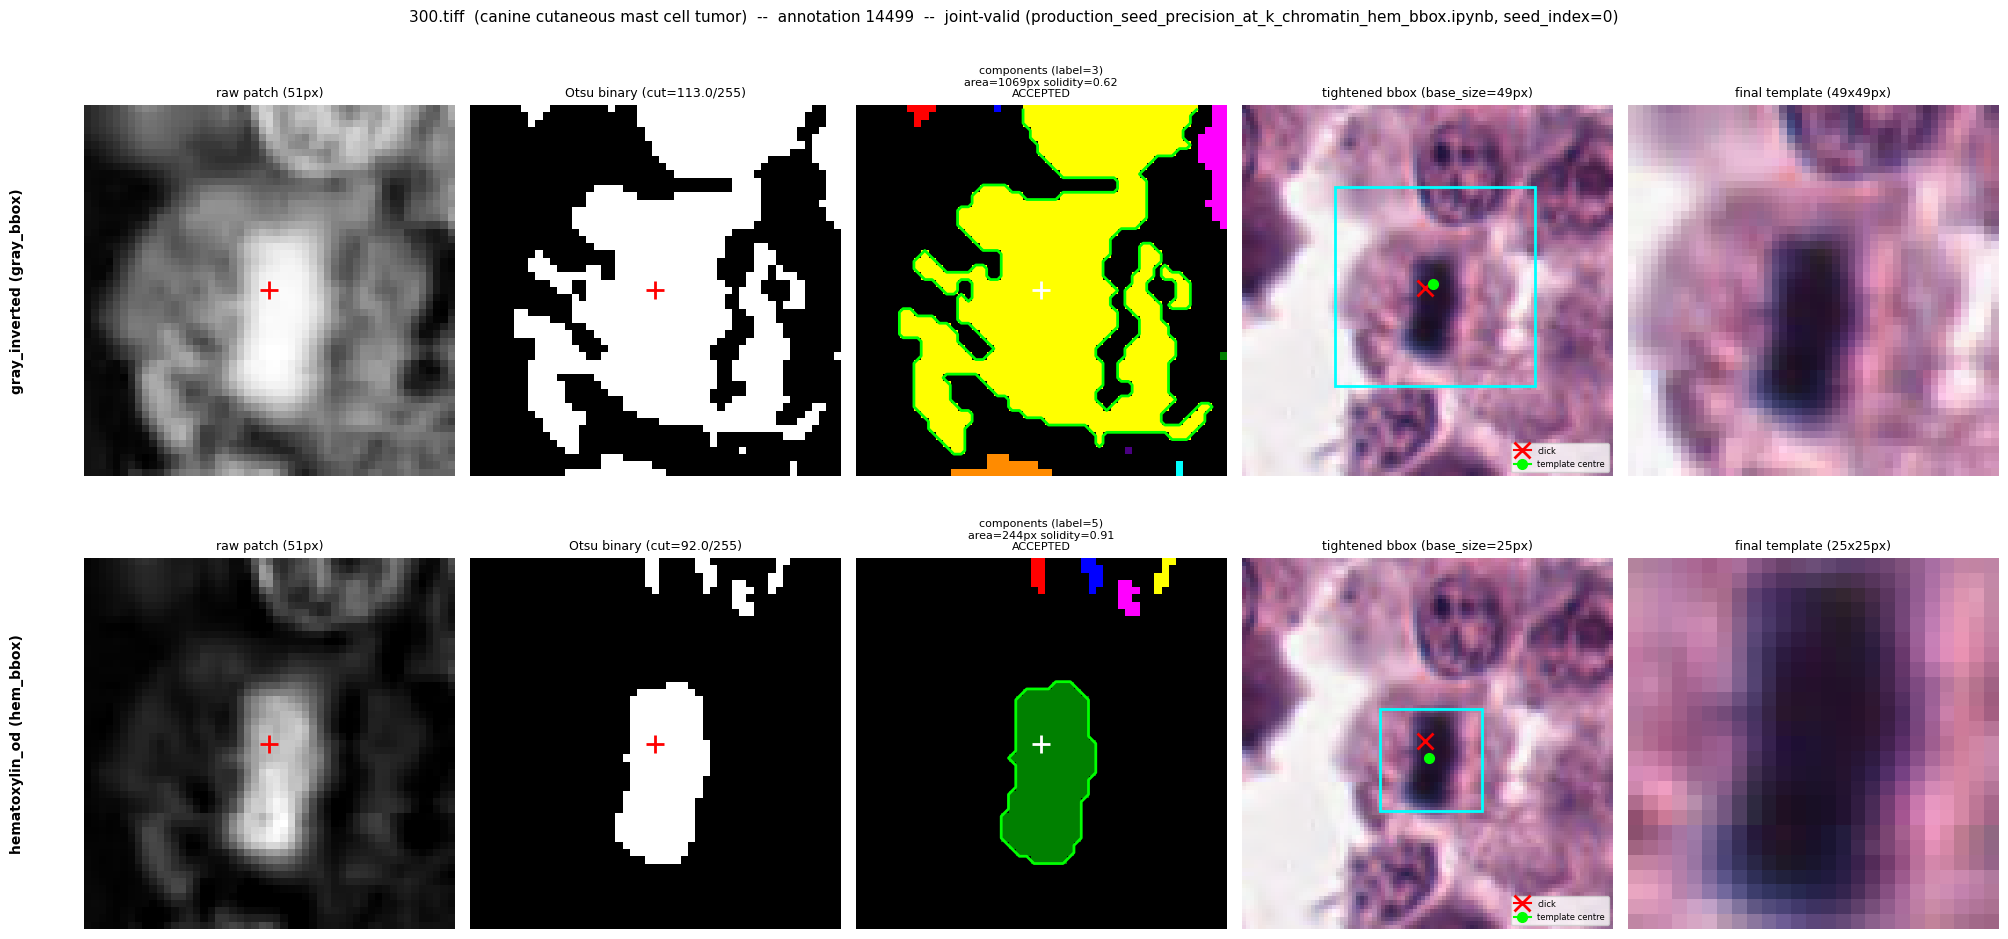

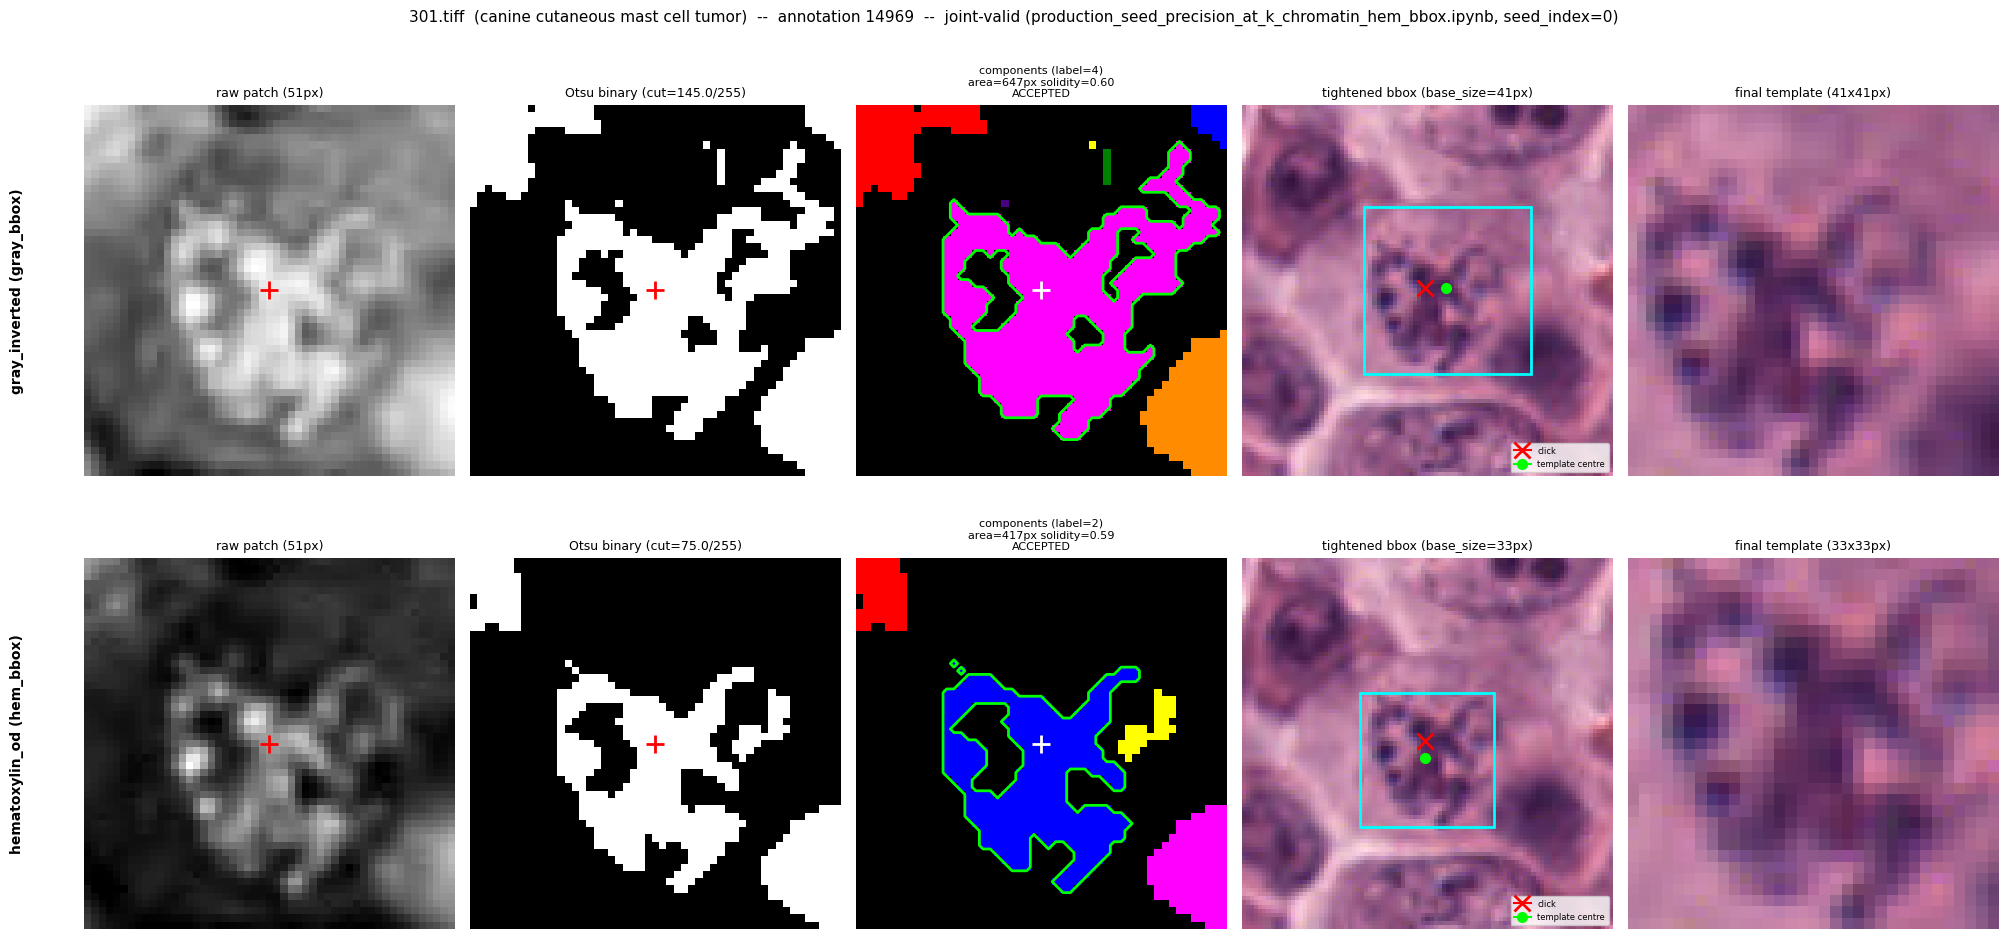

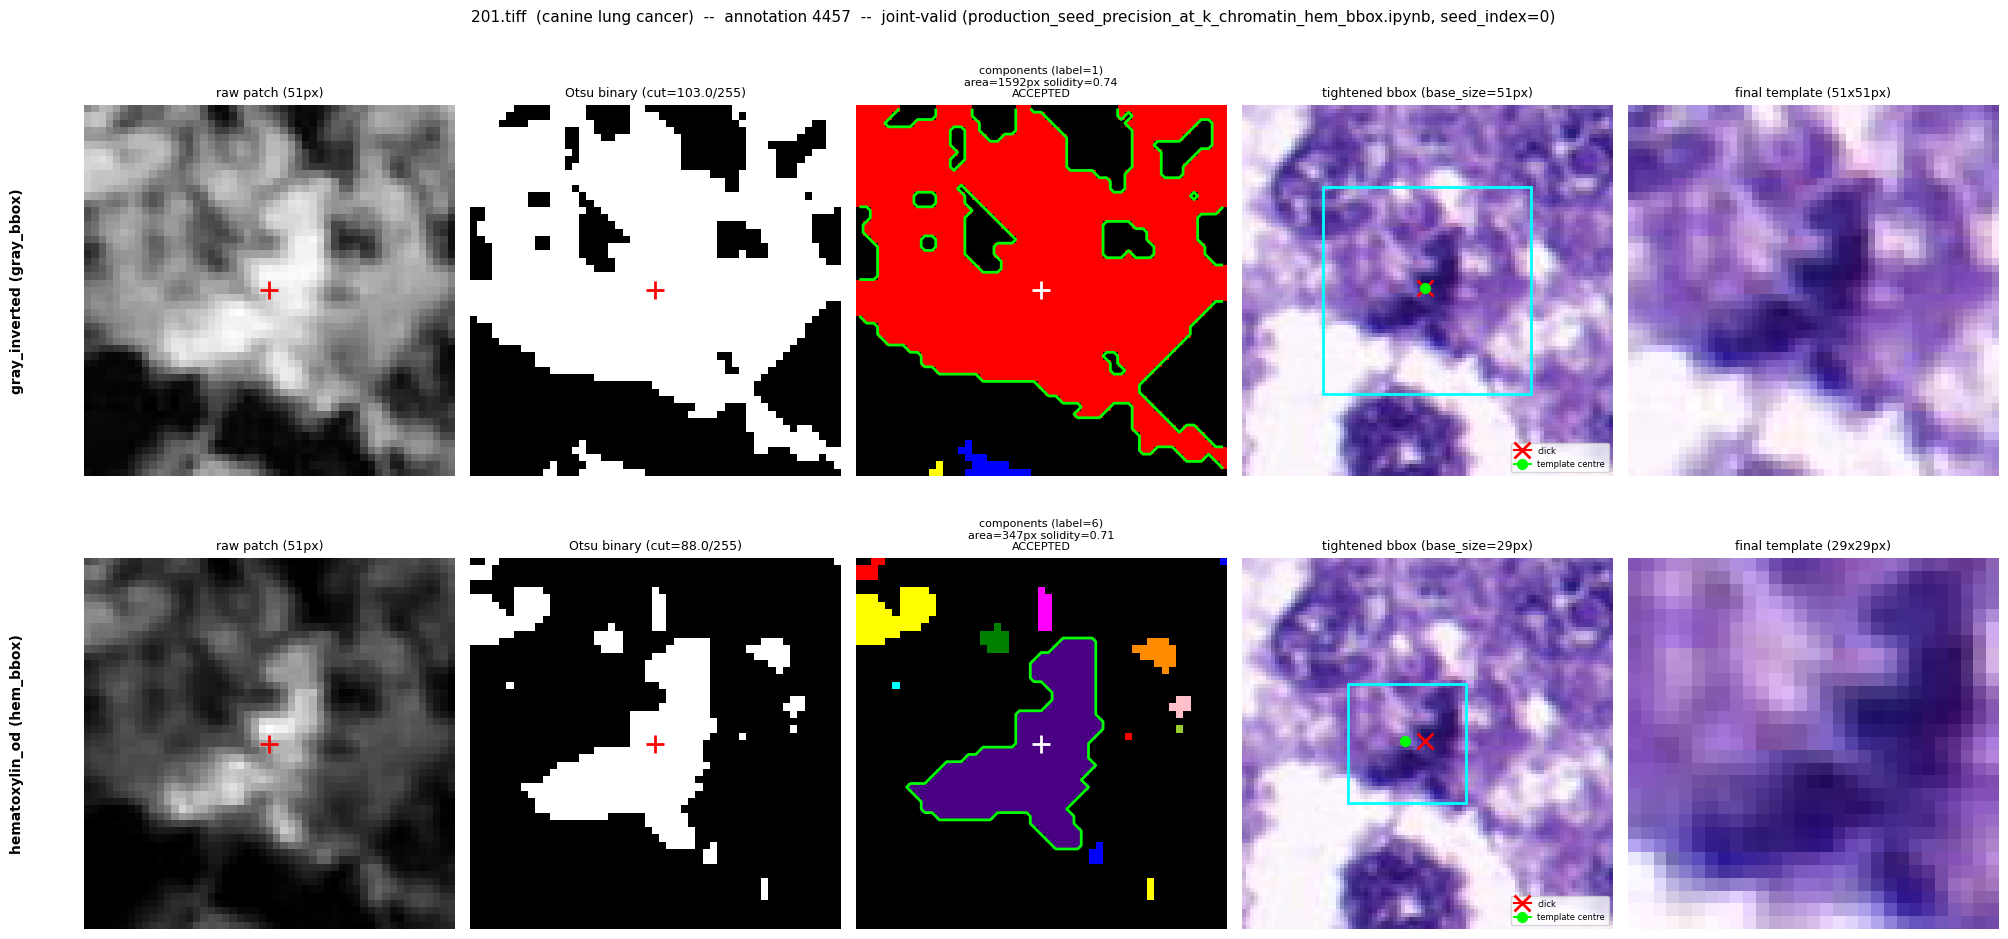

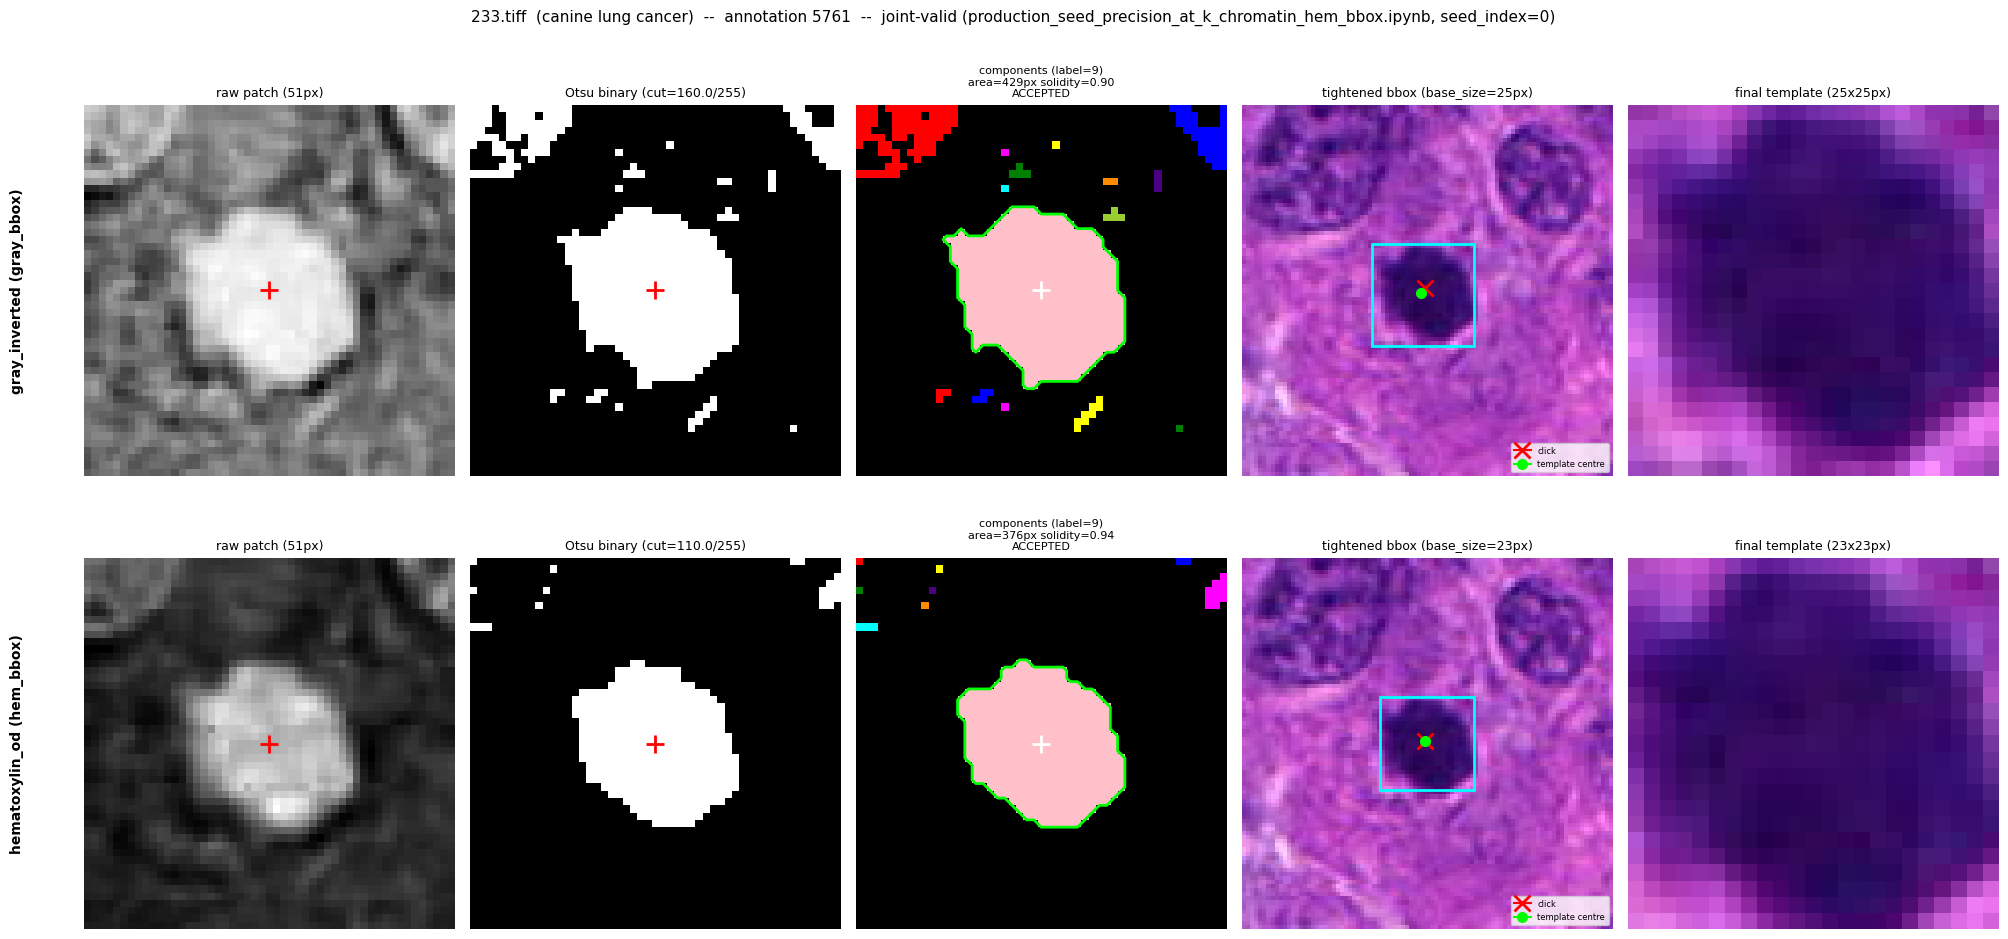

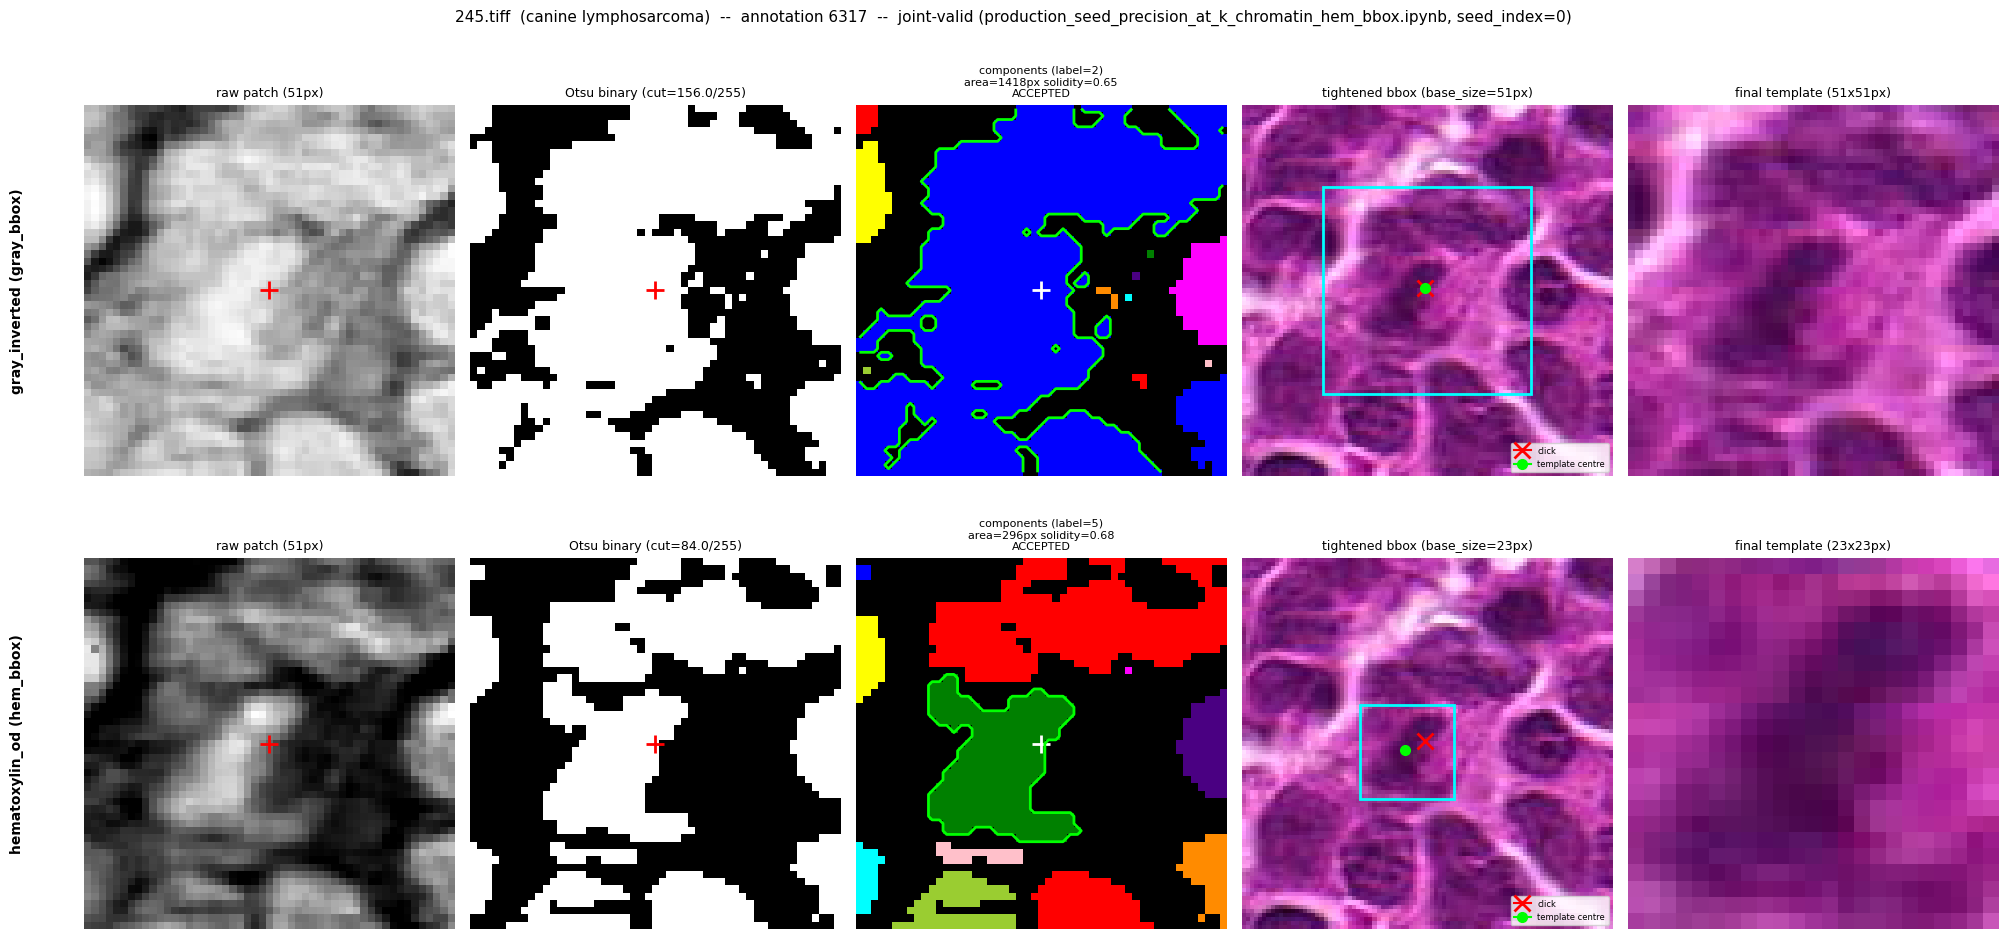

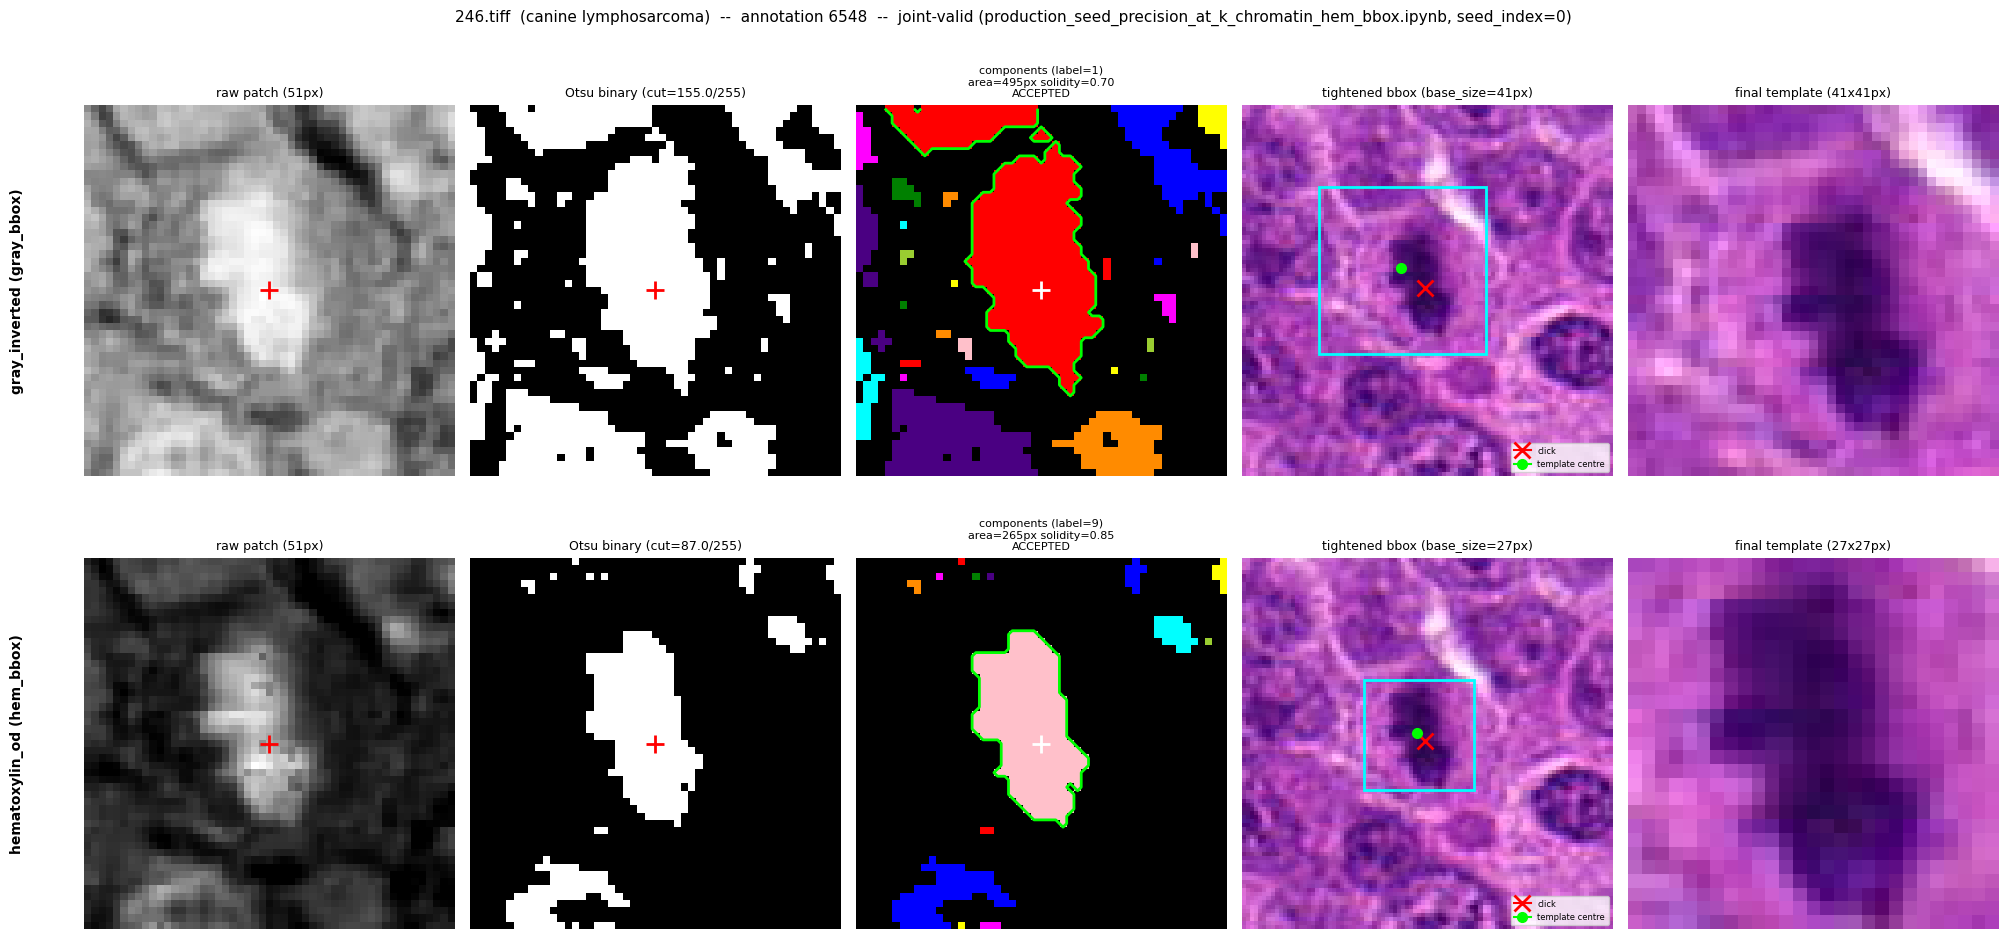

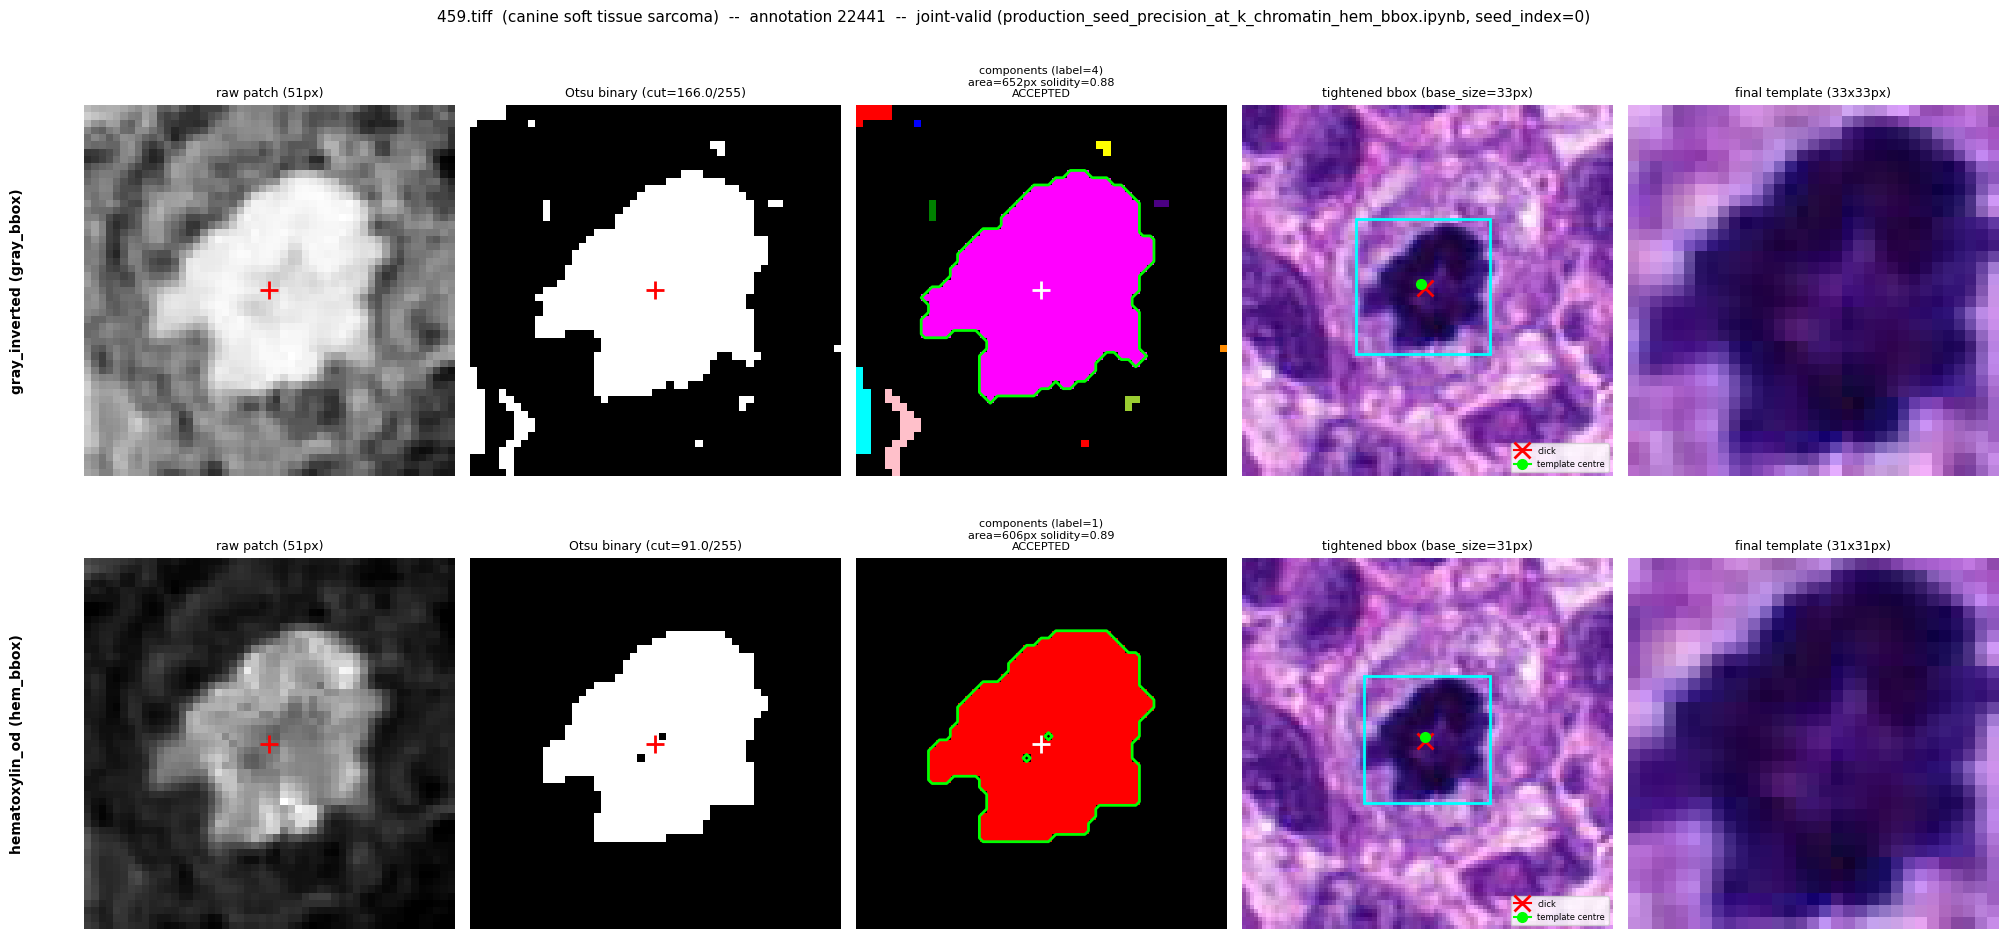

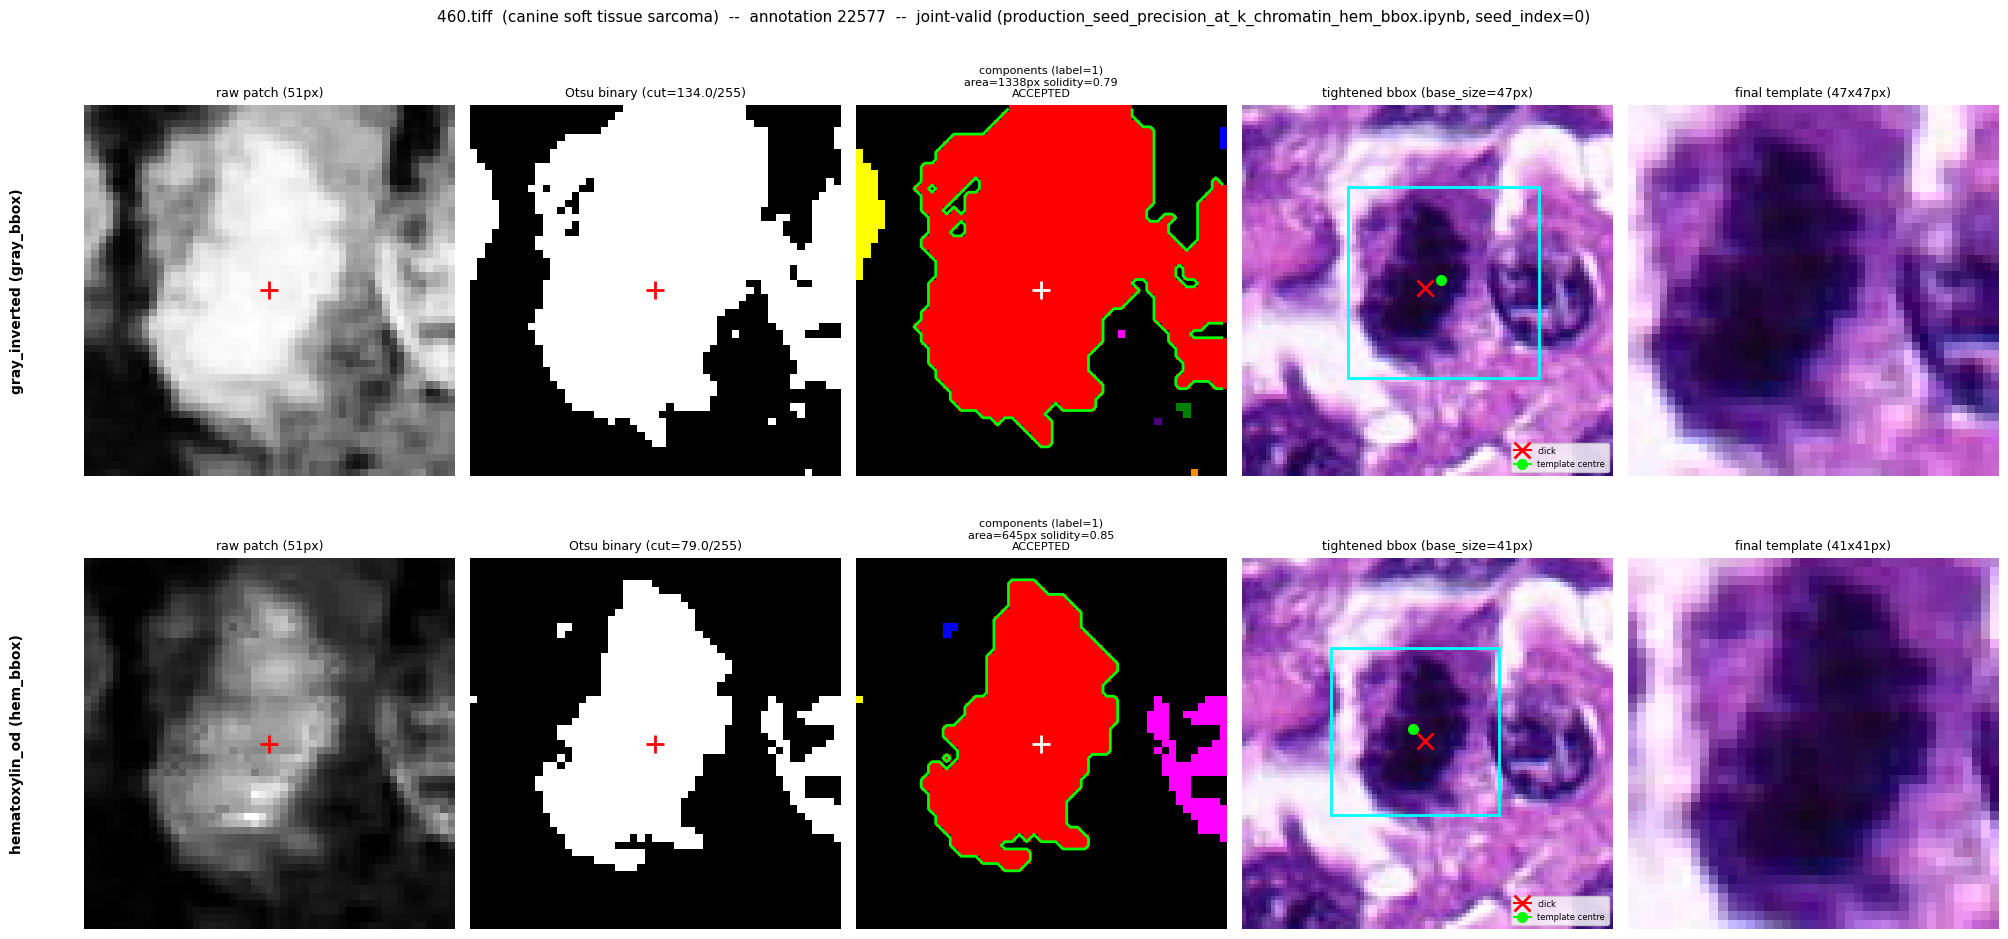

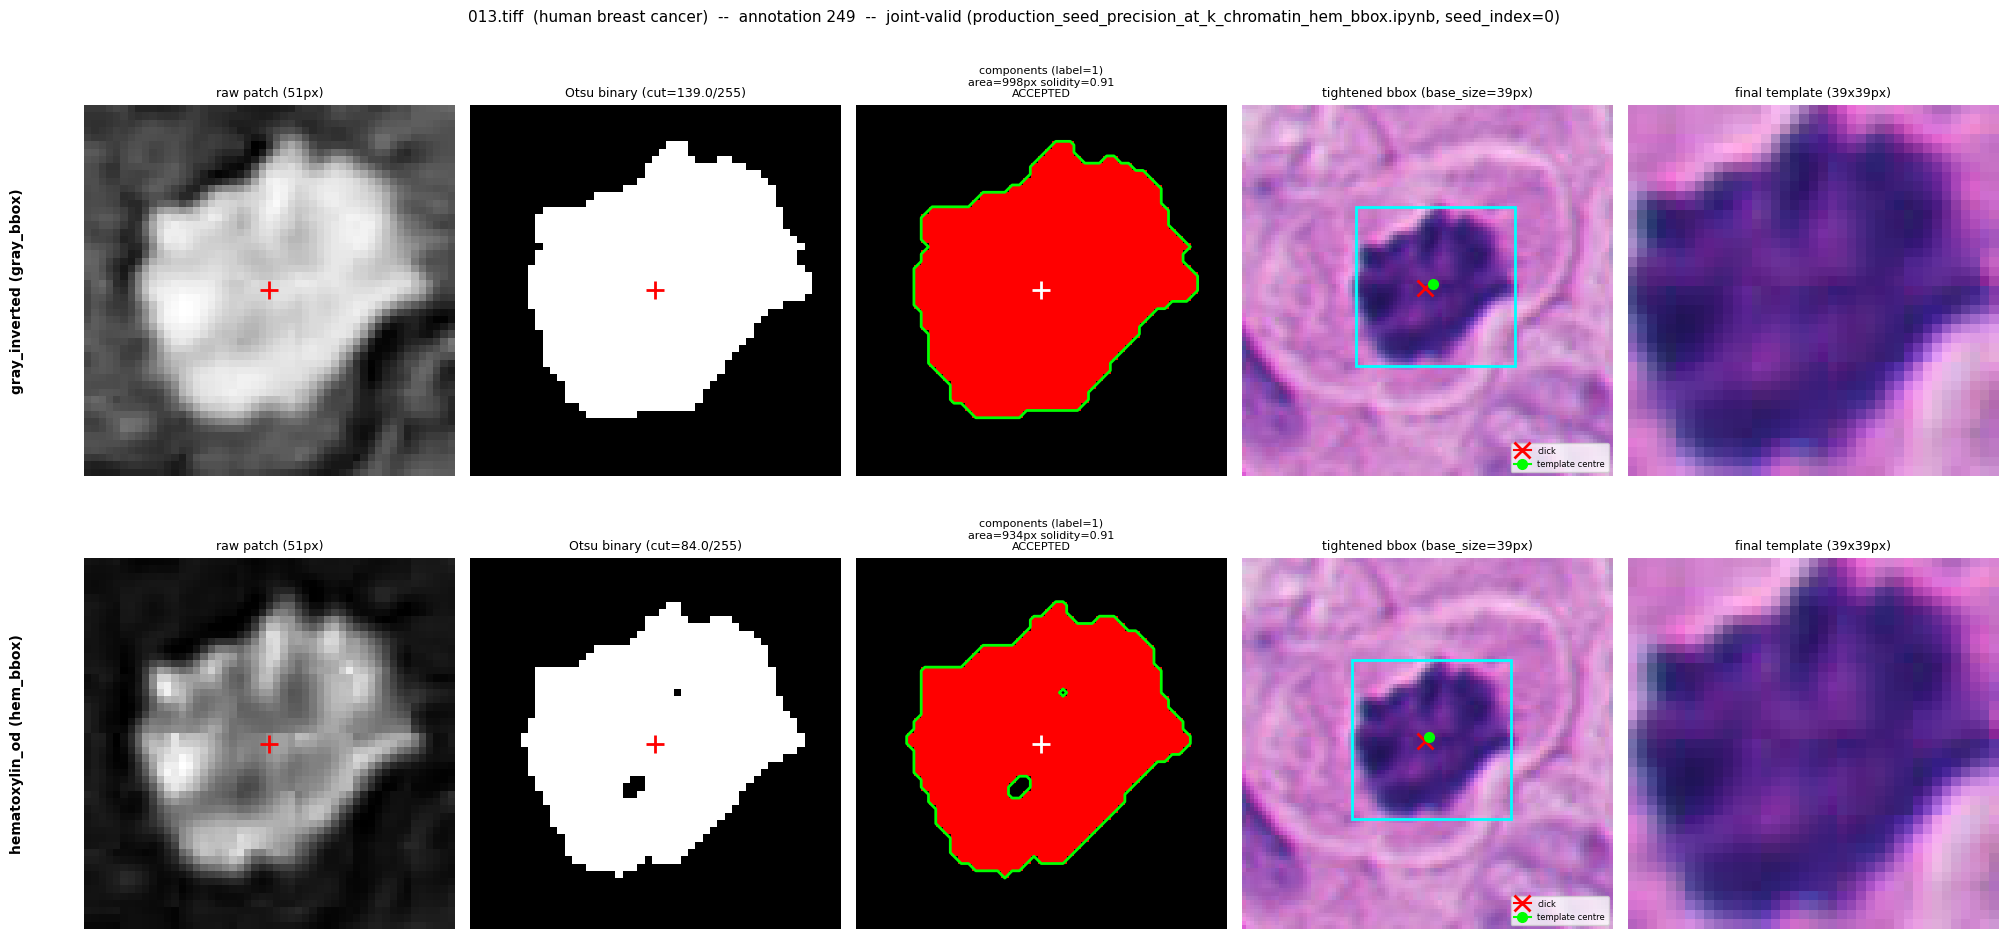

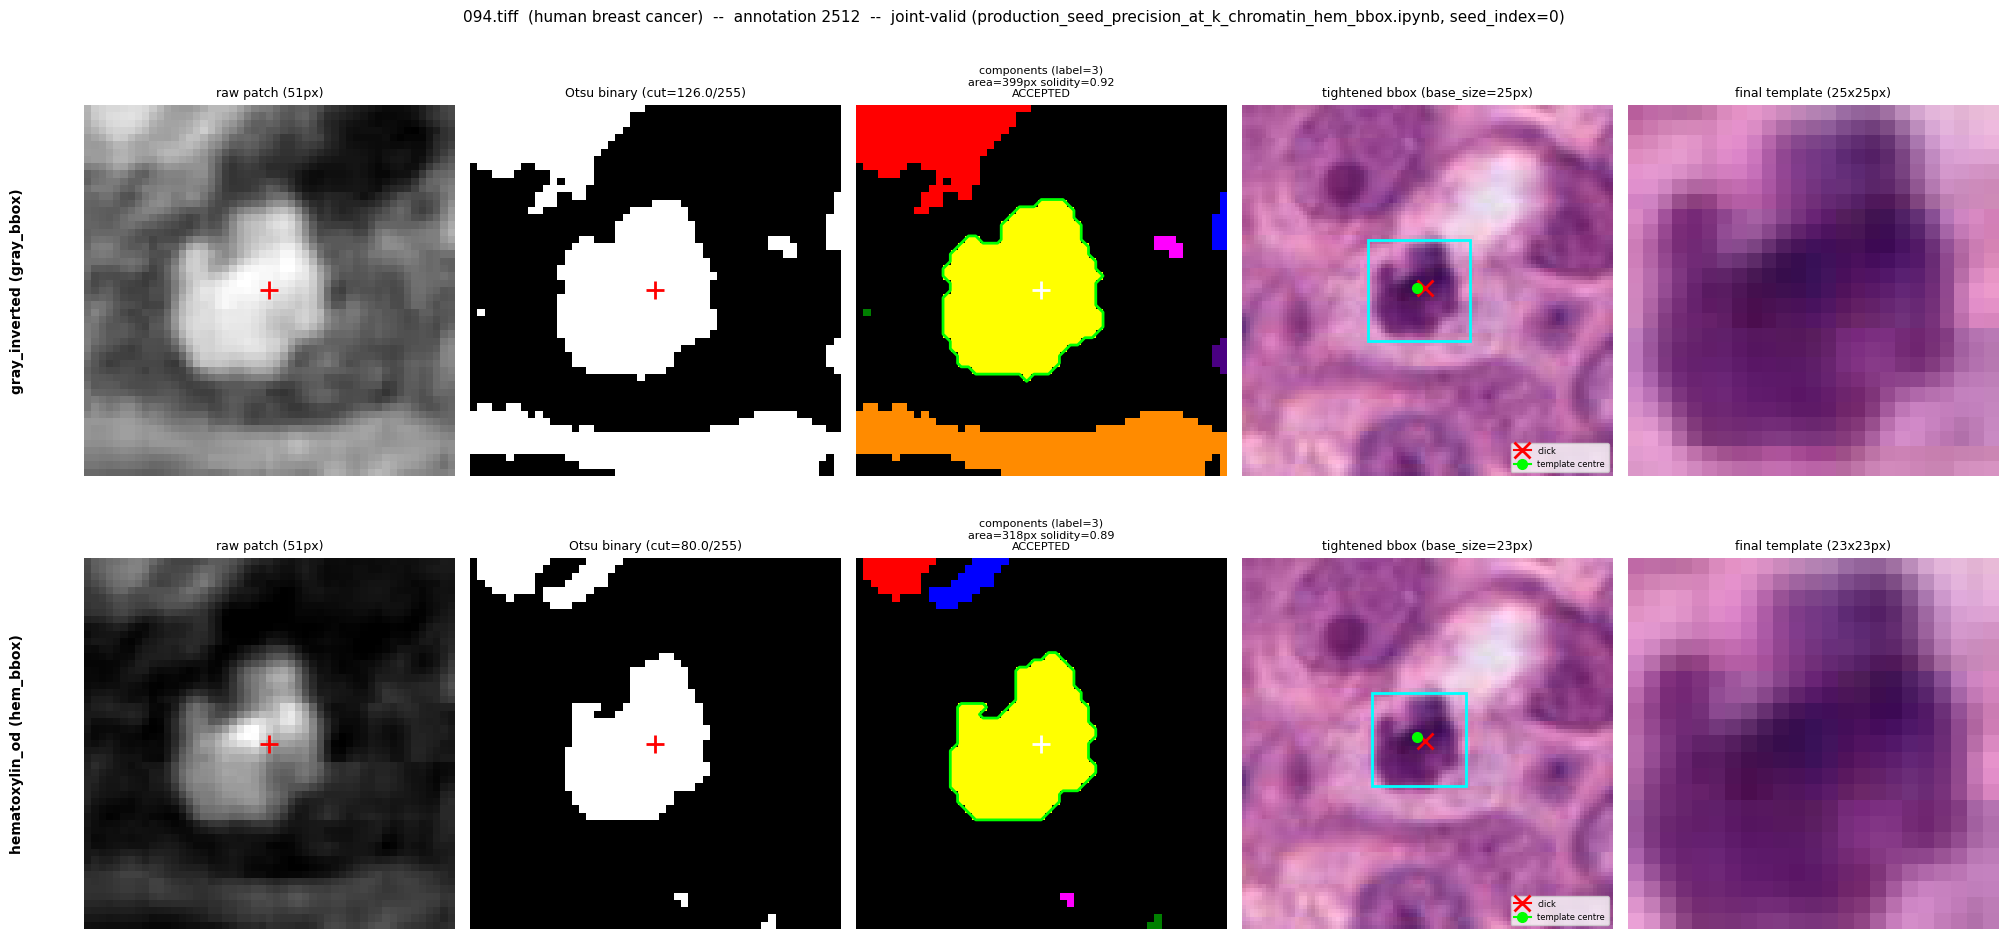

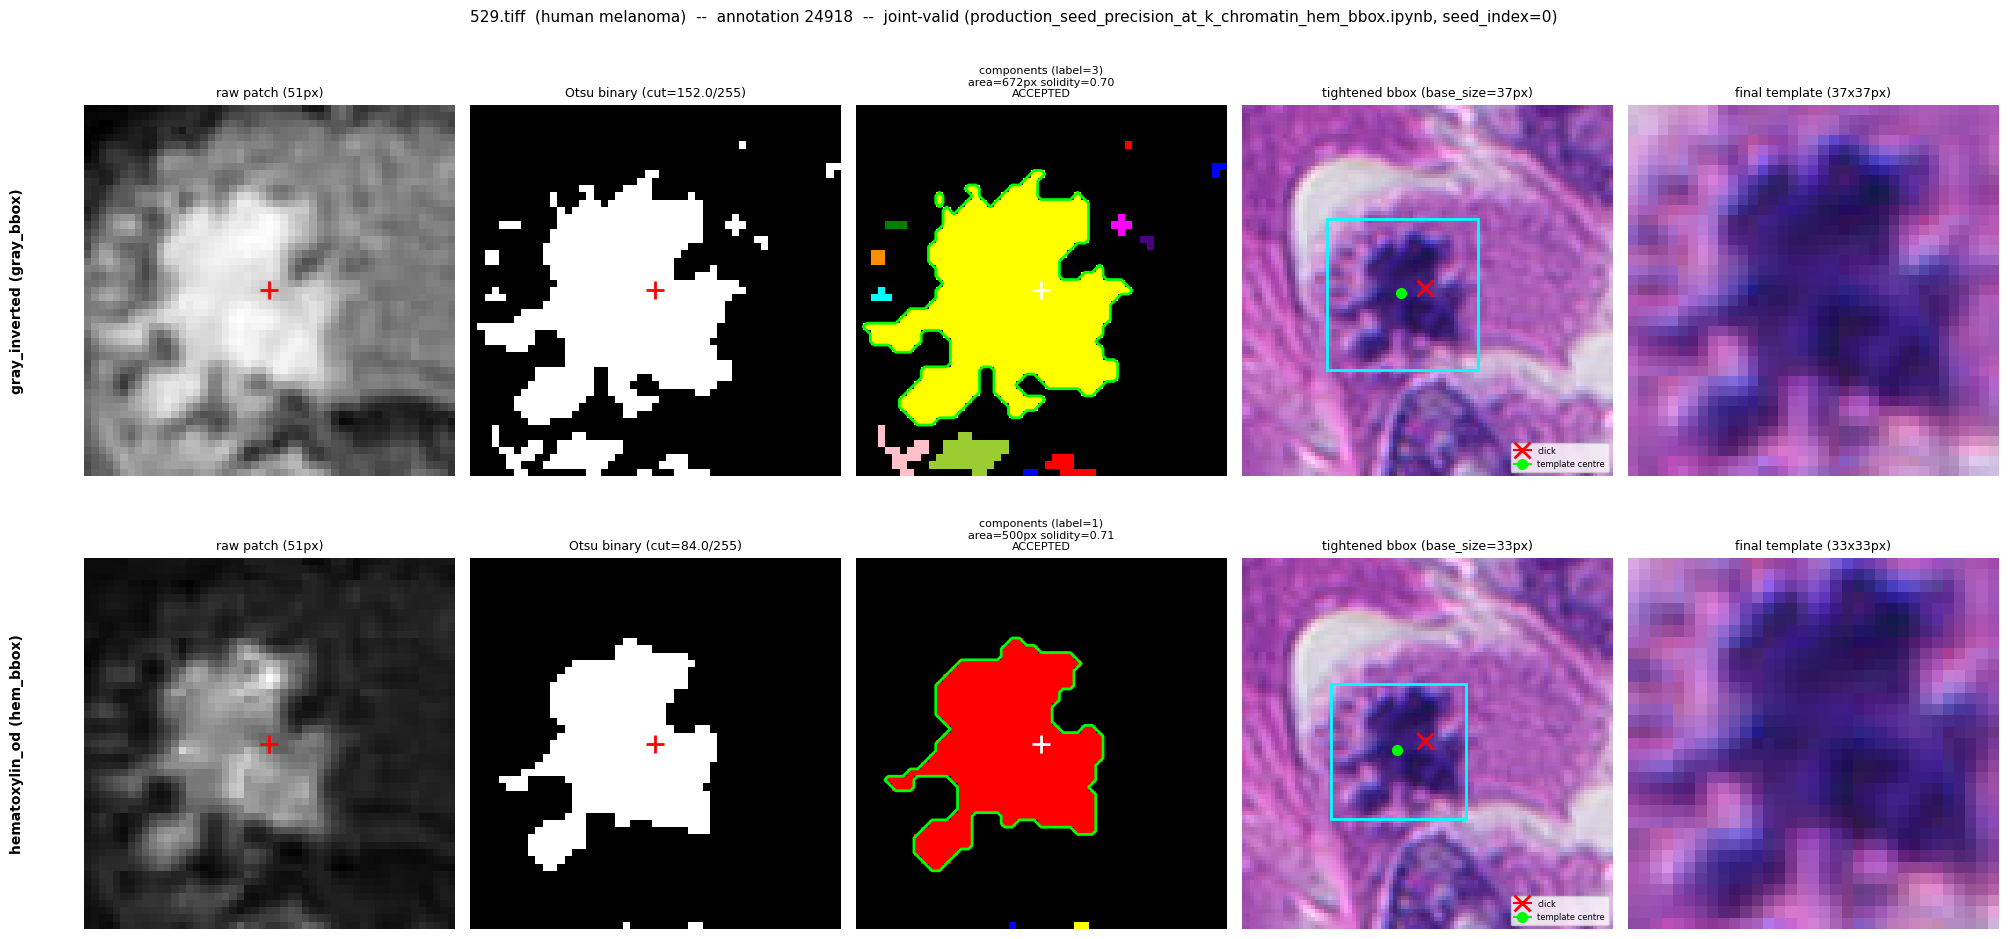

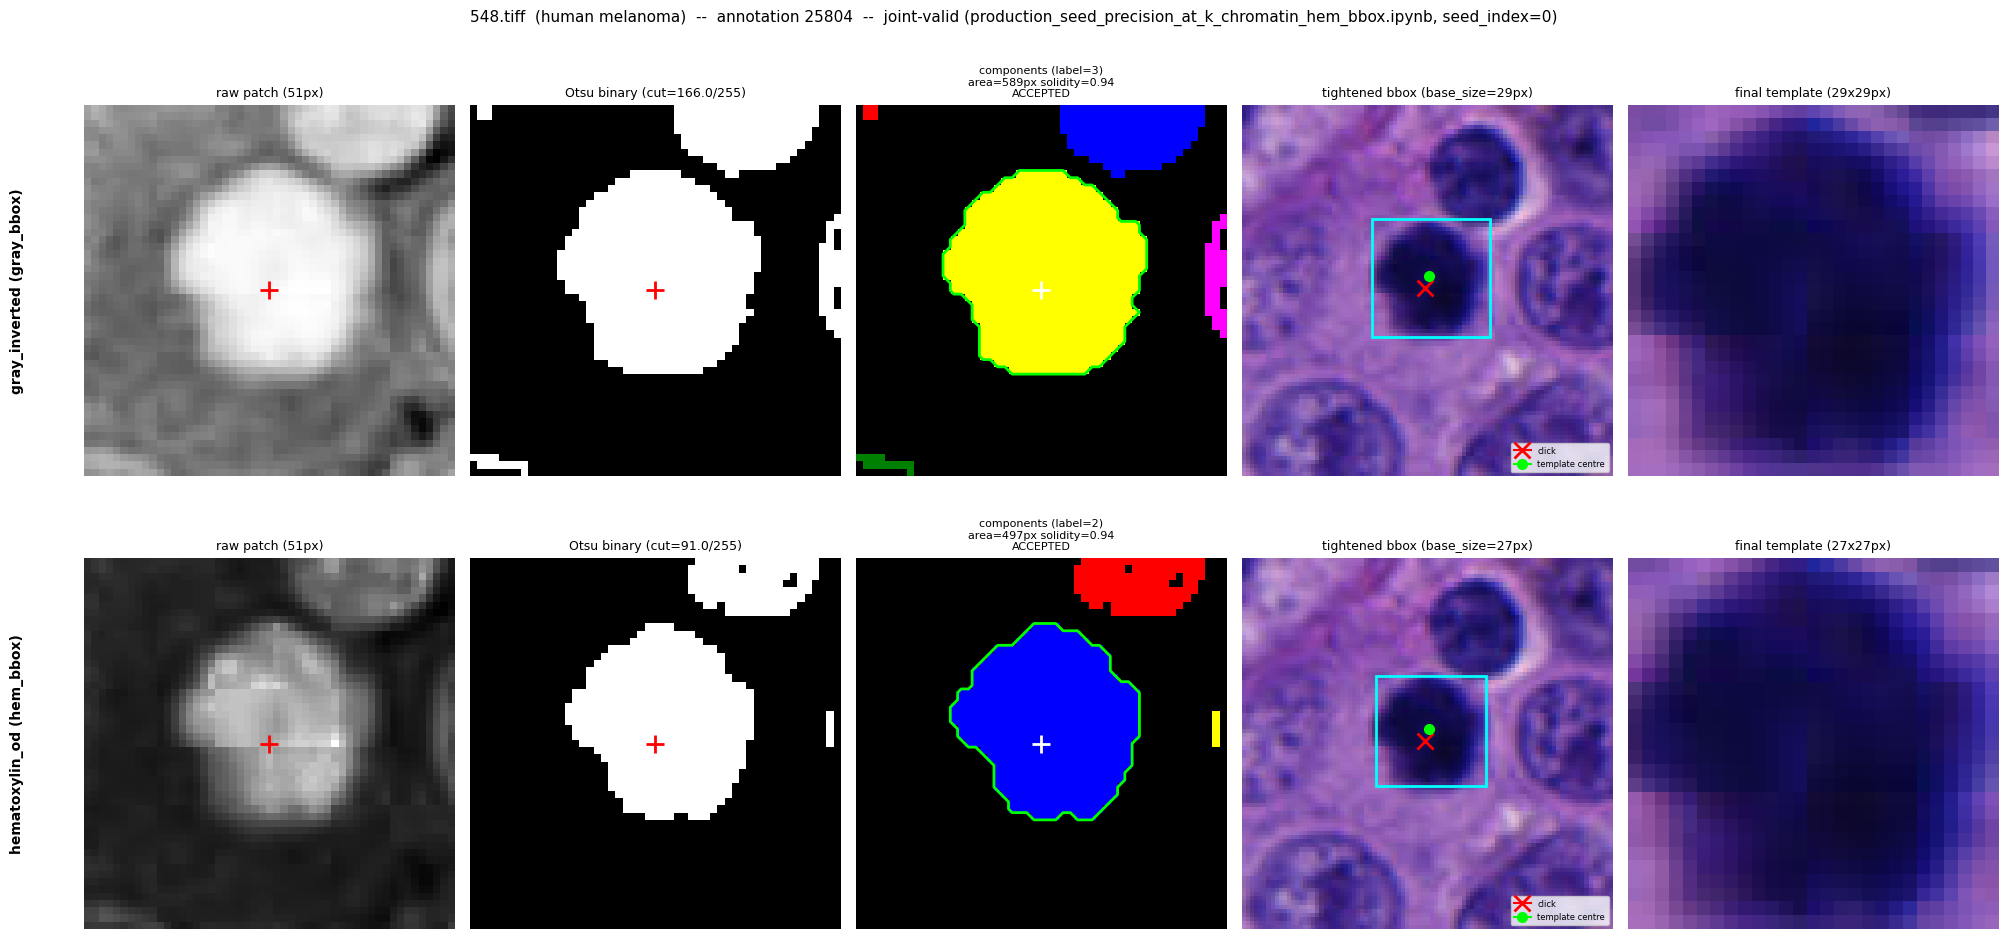

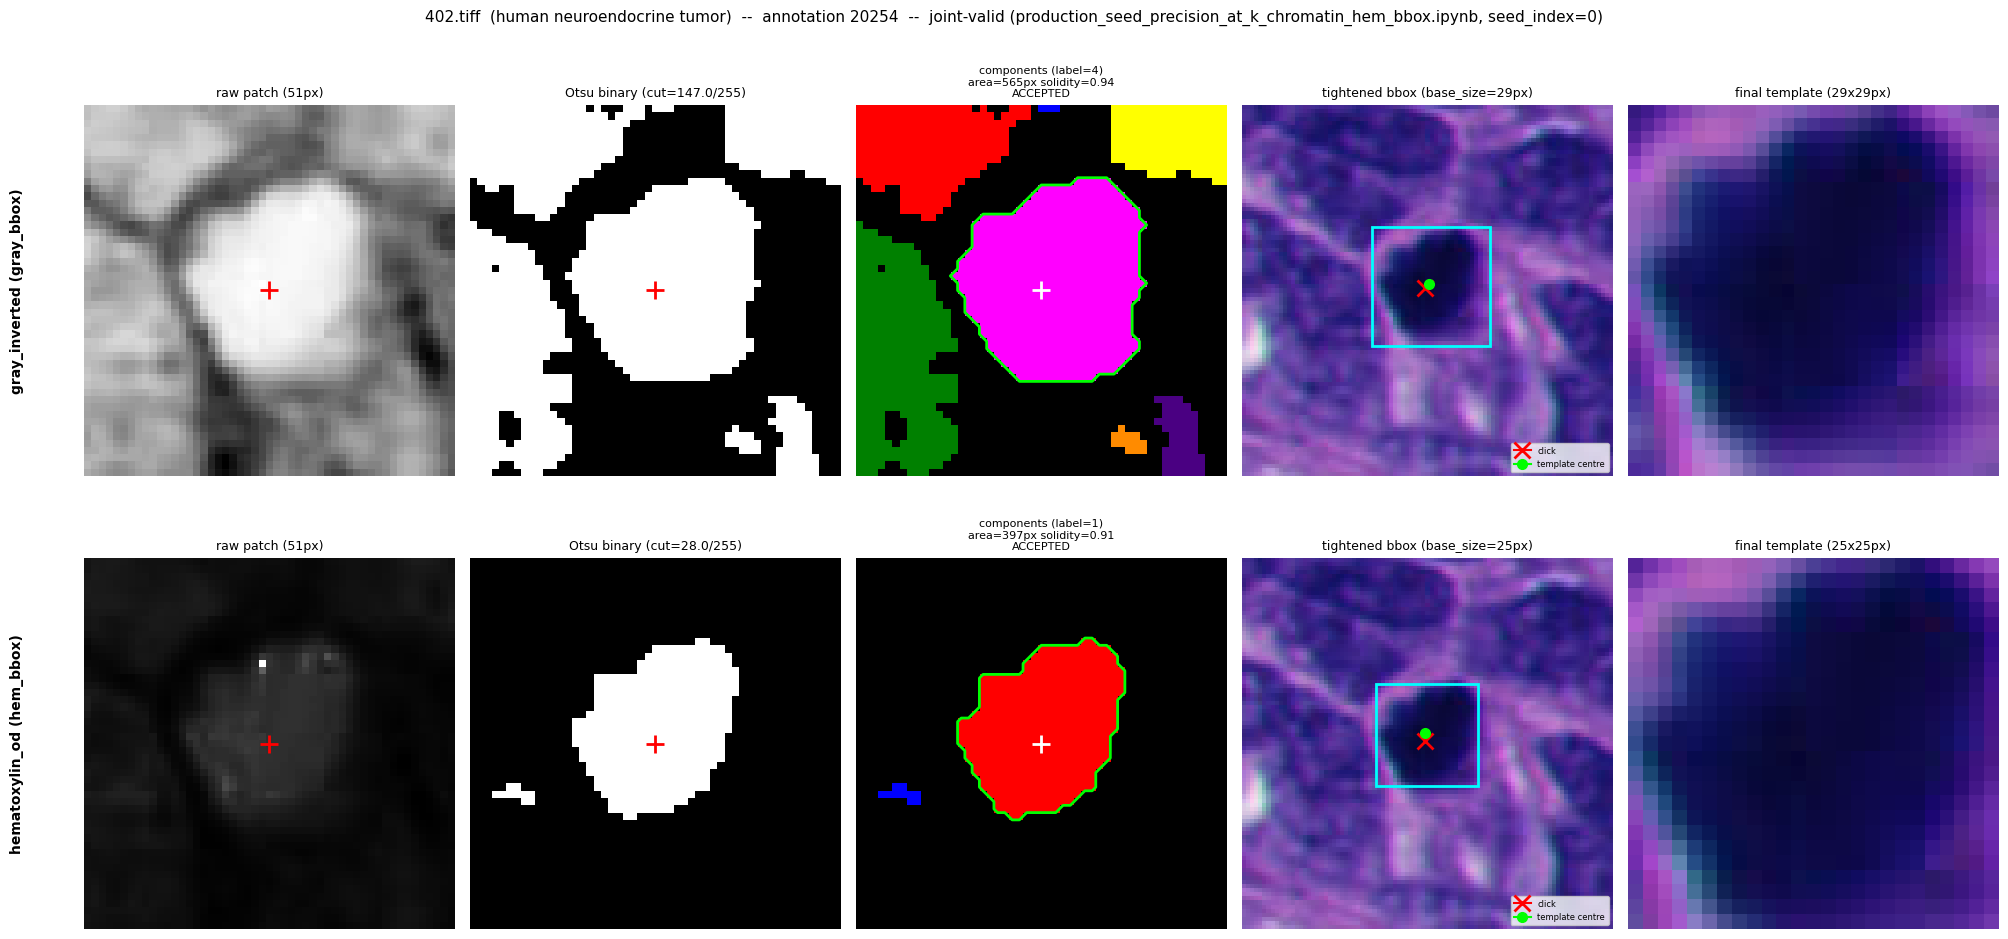

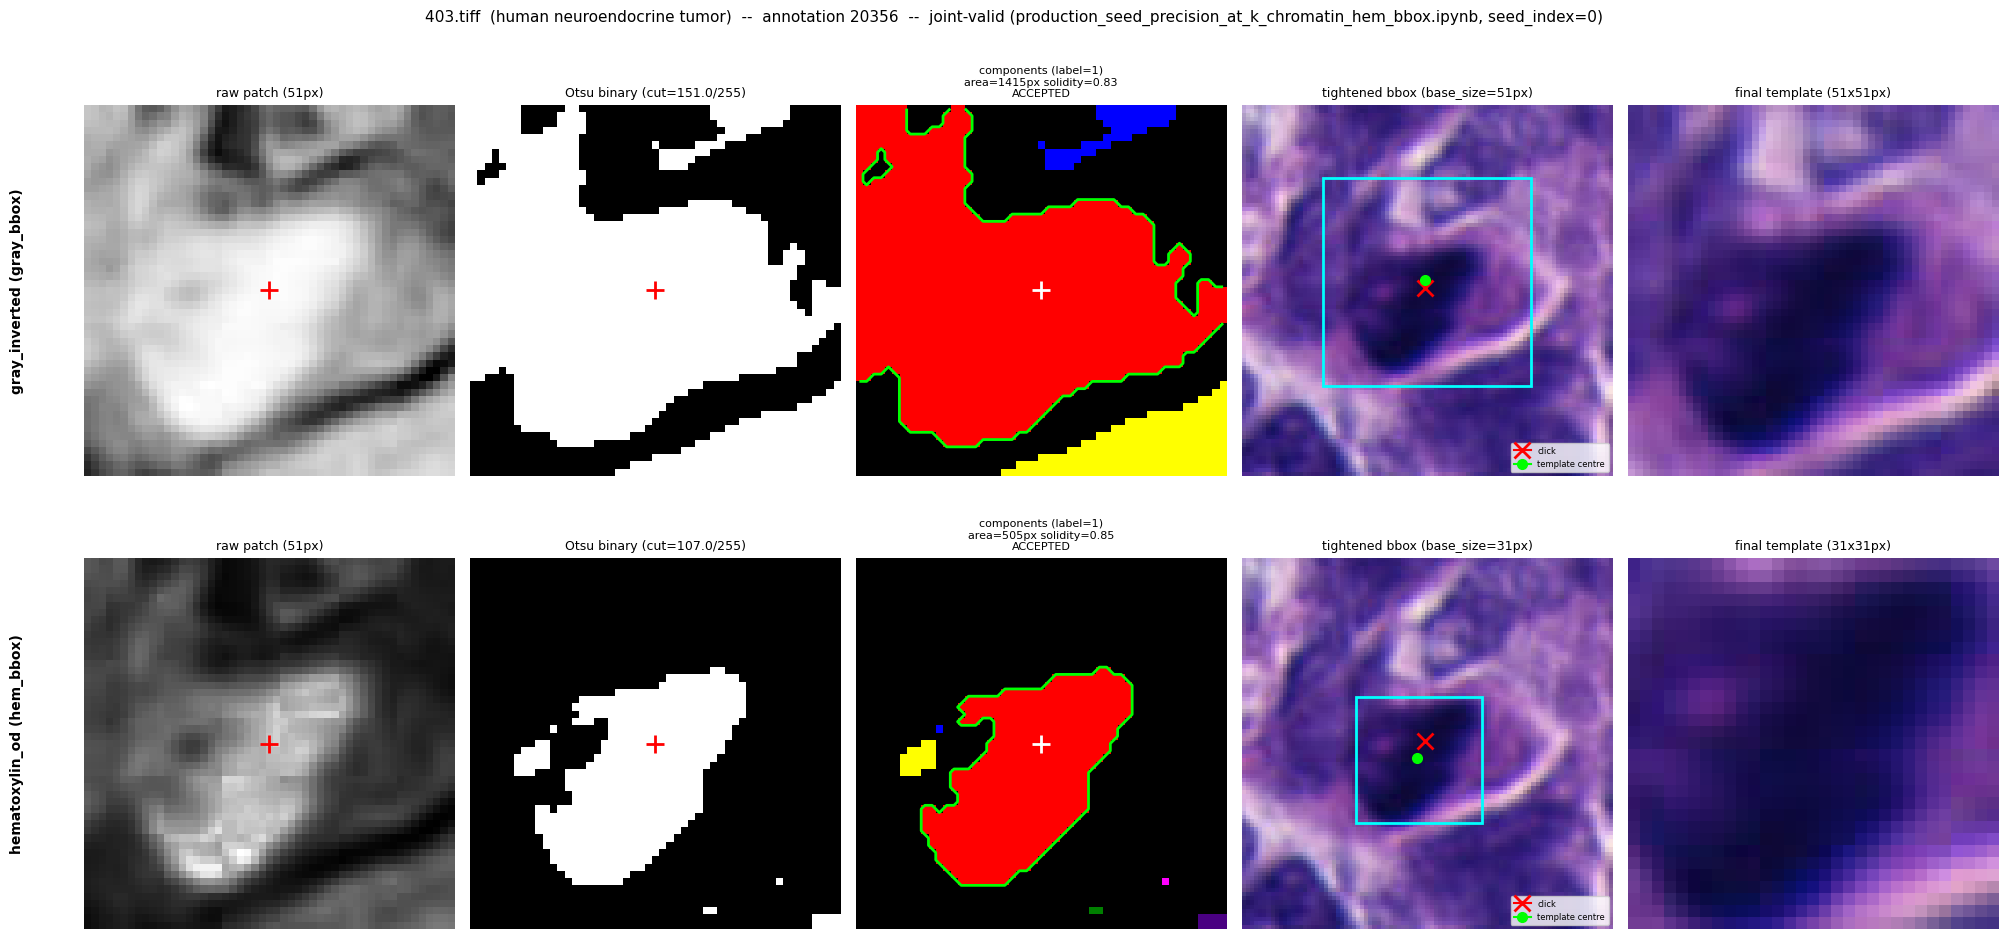

accepted on both channels: 14/14 ROIs (28/28 (ROI, channel) renders)
cross-check mismatches against ss.tighten_box_otsu / ss.tightened_template_box / cell 5's own recording: 0


In [4]:
SUMMARY_ROWS = []
CROSS_CHECK_MISMATCHES = []
NOT_ACCEPTED = []

order = sorted(seeds.items(), key=lambda kv: (kv[1]['domain'], kv[0]))

for fn, s in order:
    domain, ann_id, cx, cy = s['domain'], s['ann_id'], s['cx'], s['cy']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')

    fig, axes = plt.subplots(2, 5, figsize=(20, 9.6))
    for r, (ch_label, ch_key) in enumerate(CHANNELS.items()):
        chan = ch.to_channel(rgb, ch_key)
        res = explore_tightening(chan, cx, cy)

        if not res['accepted']:
            NOT_ACCEPTED.append((fn, ann_id, ch_key, res['reason']))

        # cross-check against the real functions -- not just a visual approximation of them
        official_bbox = ss.tighten_box_otsu(res['patch']) if res['patch'] is not None else None
        if (official_bbox is None) != (not res['accepted']):
            CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'accept/refuse disagrees'))
        elif res['accepted'] and official_bbox != res['bbox']:
            CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'bbox disagrees'))
        if res['patch'] is not None:
            official_tpl = ss.tightened_template_box(chan, cx, cy)
            if (official_tpl is None) != (not res['accepted']):
                CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'tightened_template_box accept/refuse disagrees'))
            elif res['accepted']:
                obs, ocx, ocy = official_tpl
                if obs != res['base_size'] or abs(ocx - res['center_xy'][0]) > 1e-9 or abs(ocy - res['center_xy'][1]) > 1e-9:
                    CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'tightened_template_box result disagrees'))

        # second cross-check: does this render agree with the seed-draw step's own recording
        # (cell 5, r_by_condition) -- two different code paths, the same click, must agree
        condition = 'hem_bbox' if ch_key == 'hematoxylin_od' else 'gray_bbox'
        seed_base, seed_cx, seed_cy = s['r_by_condition'][condition]
        if res['accepted'] and (seed_base != res['base_size']
                                or abs(seed_cx - res['center_xy'][0]) > 1e-9
                                or abs(seed_cy - res['center_xy'][1]) > 1e-9):
            CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'disagrees with cell 5\'s own draw_joint_valid_seed recording'))

        plot_channel_row(axes[r], ch_label, res, rgb, cx, cy)

        area = int(res['region'].area) if res['region'] is not None else None
        solidity = round(float(res['region'].solidity), 4) if res['region'] is not None else None
        bbox_h = res['bbox'][1] - res['bbox'][0] if res['bbox'] is not None else None
        bbox_w = res['bbox'][3] - res['bbox'][2] if res['bbox'] is not None else None
        right_censored = bool(res['bbox'] is not None and (bbox_h == OTSU_WINDOW or bbox_w == OTSU_WINDOW))
        offset_px = (float(np.hypot(res['center_xy'][0] - cx, res['center_xy'][1] - cy))
                    if res['center_xy'] is not None else None)

        SUMMARY_ROWS.append(dict(domain=domain, file_name=fn, ann_id=ann_id, channel=ch_key,
                                 condition=condition, accepted=res['accepted'],
                                 base_size=res['base_size'], area=area, solidity=solidity,
                                 bbox_h=bbox_h, bbox_w=bbox_w, right_censored=right_censored,
                                 offset_from_click_px=round(offset_px, 3) if offset_px is not None else None,
                                 reason=None if res['accepted'] else res['reason']))

    fig.suptitle(f'{fn}  ({domain})  --  annotation {ann_id}  --  joint-valid (production_seed_precision_at_k_chromatin_hem_bbox.ipynb, seed_index=0)',
                fontsize=11, y=1.01)
    fig.tight_layout(h_pad=3.0)
    fig.savefig(f'{OUT_PREFIX}_{fn.replace(".tiff","")}_{ann_id}.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print(f'accepted on both channels: {14 - len(NOT_ACCEPTED)}/14 ROIs '
     f'({28 - len(NOT_ACCEPTED)}/28 (ROI, channel) renders)')
if NOT_ACCEPTED:
    print('NOT ACCEPTED (unexpected for a joint-valid click):', NOT_ACCEPTED)
assert not NOT_ACCEPTED, ('a joint-valid click was refused when re-rendered here -- the '
                          'visualization or the draw diverged from tightened_template_box; see above')

print(f'cross-check mismatches against ss.tighten_box_otsu / ss.tightened_template_box / '
     f"cell 5's own recording: {len(CROSS_CHECK_MISMATCHES)}")
if CROSS_CHECK_MISMATCHES:
    print(CROSS_CHECK_MISMATCHES)
assert not CROSS_CHECK_MISMATCHES, 'the visualization diverged from the real tightening functions -- see above'

## Step 3 -- summary table

One row per (ROI, channel) -- 14 x 2 = 28 rows, all `accepted=True` (checked above).
`right_censored` flags a component whose bounding box spans the *entire* 51px Otsu window on
at least one axis -- its `base_size` is then a lower bound on the true nuclear-outline size, not
a measurement of one (the window simply isn't big enough to contain it), a distinction
`tightening_process_hem_vs_gray.ipynb` first surfaced on its own smaller sample.

In [5]:
SUMMARY = pd.DataFrame(SUMMARY_ROWS)
SUMMARY.to_csv(f'{OUT_PREFIX}_summary.csv', index=False)
print(f'-> {OUT_PREFIX}_summary.csv  ({len(SUMMARY)} rows = 14 ROIs x 2 channels)')
print(f"accepted: {int(SUMMARY['accepted'].sum())}/{len(SUMMARY)}")

hem = SUMMARY[SUMMARY['condition'] == 'hem_bbox'].set_index('file_name')
gray = SUMMARY[SUMMARY['condition'] == 'gray_bbox'].set_index('file_name')
DELTA = pd.DataFrame({
    'domain': hem['domain'],
    'ann_id': hem['ann_id'],
    'base_hem': hem['base_size'], 'base_gray': gray['base_size'],
    'delta_base_size': hem['base_size'] - gray['base_size'],
    'area_hem': hem['area'], 'area_gray': gray['area'],
    'solidity_hem': hem['solidity'], 'solidity_gray': gray['solidity'],
    'right_censored_gray': gray['right_censored'], 'right_censored_hem': hem['right_censored'],
    'offset_hem_px': hem['offset_from_click_px'], 'offset_gray_px': gray['offset_from_click_px'],
}).sort_values('delta_base_size')
DELTA['pct_change_base_size'] = (100 * DELTA['delta_base_size'] / DELTA['base_gray']).round(1)
DELTA.to_csv(f'{OUT_PREFIX}_delta.csv')
print(f'-> {OUT_PREFIX}_delta.csv  ({len(DELTA)} rows = 14 ROIs)')

print(f"\nbase_size: {int((DELTA['delta_base_size'] < 0).sum())} shrink, "
     f"{int((DELTA['delta_base_size'] > 0).sum())} grow, "
     f"{int((DELTA['delta_base_size'] == 0).sum())} unchanged  |  "
     f"median change {DELTA['pct_change_base_size'].median():.1f}%")
print(f"right-censored on gray_bbox (bbox spans the full {OTSU_WINDOW}px window): "
     f"{int(DELTA['right_censored_gray'].sum())}/14  |  on hem_bbox: {int(DELTA['right_censored_hem'].sum())}/14")
print(f"median component area: hem_bbox={SUMMARY[SUMMARY['condition']=='hem_bbox']['area'].median():.0f}px  "
     f"gray_bbox={SUMMARY[SUMMARY['condition']=='gray_bbox']['area'].median():.0f}px")

DELTA

-> seedrefine14_summary.csv  (28 rows = 14 ROIs x 2 channels)
accepted: 28/28


-> seedrefine14_delta.csv  (14 rows = 14 ROIs)

base_size: 13 shrink, 0 grow, 1 unchanged  |  median change -13.3%
right-censored on gray_bbox (bbox spans the full 51px window): 3/14  |  on hem_bbox: 0/14
median component area: hem_bbox=407px  gray_bbox=662px


,domain,ann_id,base_hem,base_gray,delta_base_size,area_hem,area_gray,solidity_hem,solidity_gray,right_censored_gray,right_censored_hem,offset_hem_px,offset_gray_px,pct_change_base_size
file_name,,,,,,,,,,,,,,
245.tiff,canine lymphosarcoma,6317,23,51,-28,296,1418,0.6820,0.6529,True,False,5.385,0.000,-54.9
300.tiff,canine cutaneous mast cell tumor,14499,25,49,-24,244,1069,0.9104,0.6186,False,False,4.123,2.500,-49.0
201.tiff,canine lung cancer,4457,29,51,-22,347,1592,0.7140,0.7443,True,False,5.000,0.500,-43.1
403.tiff,human neuroendocrine tumor,20356,31,51,-20,505,1415,0.8516,0.8328,True,False,4.924,2.000,-39.2
246.tiff,canine lymphosarcoma,6548,27,41,-14,265,495,0.8548,0.7011,False,False,2.500,8.515,-34.1
301.tiff,canine cutaneous mast cell tumor,14969,33,41,-8,417,647,0.5890,0.6013,False,False,4.500,5.500,-19.5
460.tiff,canine soft tissue sarcoma,22577,41,47,-6,645,1338,0.8453,0.7852,False,False,3.905,4.472,-12.8
529.tiff,human melanoma,24918,33,37,-4,500,672,0.7062,0.6985,False,False,6.671,6.083,-10.8
402.tiff,human neuroendocrine tumor,20254,25,29,-4,397,565,0.9085,0.9370,False,False,2.000,1.803,-13.8


## Closing summary

**On these 14 clicks -- every one accepted by both channels -- `hematoxylin_od` still gives a
smaller, more chromatin-concentrated box than `gray_inverted`, on 13 of 14.** `013.tiff` is the
one exception, unchanged at 39px on both channels; every other ROI shrinks, median -13.3%, matching
`production_seed_precision_at_k_chromatin_hem_bbox.ipynb`'s own headline number exactly (that
notebook measures the same 14 clicks, computed independently there). This is not a refusal
effect -- unlike `tightening_process_hem_vs_gray.ipynb`'s sample, where `hematoxylin_od` outright
refused 4/14 clicks `gray_inverted` accepted, every click here already cleared both gates before
being drawn; what's shown here is the size difference *given* both channels say yes.

**Three of the 14 `gray_inverted` components are right-censored** (`201.tiff`, `245.tiff`,
`403.tiff` -- their accepted component's bounding box spans the entire 51px Otsu window on at
least one axis, visible in panel 3 of each figure as a colored blob touching the crop's edge).
Their `base_size=51` is a lower bound on the true nuclear-outline size, not a measurement of one --
the window isn't big enough to contain whatever `gray_inverted` is tracing at that click. None of
the 14 `hematoxylin_od` components hit this ceiling (largest bbox side measured here: 40px,
`460.tiff`). These three are also exactly the three largest `base_size` shrinks in the run
(-39% to -55%), so part of "hematoxylin_od's box is smaller" is a real, comparably-sized nuclear
core; part of it is that `gray_inverted`'s own number on these three ROIs is not fully measured.

**Visually, the two channels are tracing different objects, not just different-sized versions of
the same one** (compare panel 2/3 across every figure): `gray_inverted`'s Otsu cut consistently
keeps a fuller, softer region -- median accepted-component area 662px vs. `hematoxylin_od`'s
407px, on the same 51px window, same click, same image -- reading in the rendered patches as the
nuclear outline plus some surrounding halo. `hematoxylin_od`'s cut tends to confine itself to the
densest, most heavily-stained chromatin core within that same nucleus. This is consistent with
(not new evidence for) `production_seed_precision_at_k_chromatin_hem_bbox.ipynb`'s own framing:
switching the tightening channel is a real code simplification, but not a behaviourally free one
-- both notebooks now show *why*, from two independent angles (aggregate precision there, the
actual segmentation here).

**Caveats, stated plainly:**
- *n=14, single seed per ROI.* Same scope limit as the precision@K notebook this is a companion
  to -- not a claim about every possible click, only these particular ones.
- *Right-censoring affects 3/14 `gray_inverted` cells* (above) -- treat those `base_size`/`area`/
  `pct_change_base_size` numbers as "at least this different," not exact.
- *`offset_from_click_px` is not compared to a ground-truth "correct" centre* -- D8's own decision
  is that the component's bbox centre, not the click, is where the template should be built from;
  the offset column here is descriptive (how far tightening actually moved the box on this click),
  not a quality signal.